**Introduction**
La cybersécurité est devenue un enjeu stratégique majeur à l’ère numérique, où les systèmes d’information sont constamment menacés par des attaques de plus en plus sophistiquées. Ce projet vise à développer un modèle de machine learning performant capable de détecter et classifier automatiquement les types d’attaques réseau à partir d’un dataset d'intrusion, dans une logique de prévention proactive des intrusions.

**L’objectif est double** : proposer une analyse approfondie des caractéristiques des attaques pour mieux les comprendre, et entraîner plusieurs modèles de classification afin d’identifier la meilleure approche algorithmique pour détecter même les attaques les plus rares.

**Présentation complète du projet**

**1. Préparation et analyse exploratoire des données**
Le dataset utilisé provient d’un environnement simulé d’intrusion réseau. Il contient des milliers de connexions réseau, chacune annotée avec un type d’attaque ou comme "normale". Une analyse exploratoire complète a permis :

de visualiser la répartition des types d’attaques,

de détecter des déséquilibres de classes importants,

d’identifier des variables fortement asymétriques et des outliers,

de générer des statistiques descriptives et des heatmaps de corrélation.

**2. Prétraitement et ingénierie des données**
Encodage des variables catégorielles (protocol_type, service, flag).

Création de nouvelles features (total_bytes, bytes_ratio, log_src_bytes, etc.).

Normalisation et traitement des valeurs extrêmes.

Application de SMOTE pour rééquilibrer les classes minoritaires.

**3. Modélisation**
Différents modèles de classification ont été entraînés :

Random Forest (brute, avec top 5 features, avec SMOTE, avec hyperparamètres optimisés),

CatBoost (brut et optimisé),

XGBoost, LightGBM, MLPClassifier, Decision Tree, Extra Trees.

Chaque modèle a été évalué selon la précision, le rappel, le f1-score, et les résultats ont été comparés en particulier sur la classe minoritaire (classe 4).

**4. Résultats principaux**
Sans rééquilibrage, les modèles peinaient à détecter les attaques rares.

SMOTE a significativement amélioré le rappel et le f1-score des classes minoritaires.

Le Random Forest optimisé + SMOTE et le CatBoost optimisé ont donné les meilleurs compromis entre performance globale et détection des classes rares.

**5. Visualisations**
Matrices de confusion, courbes d’apprentissage, pairplots, heatmaps de corrélation, barplots de f1-score par classe.

Comparaison graphique des modèles sur la classe 4 (la plus difficile à détecter).

In [ ]:
#import des modules
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from collections import Counter
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import re

#importation du dataset
dataset = pd.read_csv("/content/drive/MyDrive/Intrusion_detection_classifier/dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Aperçu du dataset :


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


Nombre de lignes : 494021
Nombre de colonnes : 43

Types de données et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
count,494021.000000,494021,494021,494021,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,...,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021,494021
unique,NaN,3,66,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,5
top,NaN,icmp,ecr_i,SF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,smurf.,dos
freq,NaN,283602,281400,378440,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280790,391458
mean,47.979302,NaN,NaN,NaN,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,...,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412,NaN,NaN
std,707.746472,NaN,NaN,NaN,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,...,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.000000,NaN,NaN,NaN,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.000000,NaN,NaN,NaN,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.000000,NaN,NaN,NaN,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN



Répartition des types d'attaque :


,proportion,count
Attack Type,,
dos,0.792391,391458
normal,0.196911,97278
probe,0.008313,4107
r2l,0.002279,1126
u2r,0.000105,52


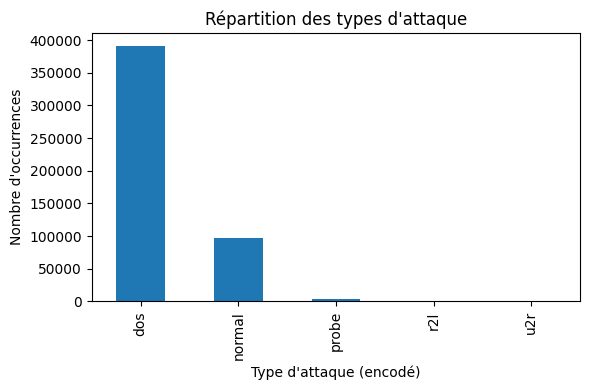

In [ ]:
# Analyse exploratoire du dataset

# Aperçu des premières lignes
print("Aperçu du dataset :")
display(dataset.head())

# Dimensions du dataset
print(f"Nombre de lignes : {dataset.shape[0]}")
print(f"Nombre de colonnes : {dataset.shape[1]}")

# Types de données et valeurs manquantes
print("\nTypes de données et valeurs manquantes :")
print(dataset.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
display(dataset.describe(include='all'))

# Répartition des classes cibles
print("\nRépartition des types d'attaque :")
display(dataset['Attack Type'].value_counts(normalize=True).rename('proportion').to_frame().join(dataset['Attack Type'].value_counts().rename('count')))

# Visualisation de la distribution des classes
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
dataset['Attack Type'].value_counts().plot(kind='bar')
plt.title("Répartition des types d'attaque")
plt.xlabel("Type d'attaque (encodé)")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

## Statistiques descriptives des variables numériques (`desc_stats`)

Le tableau `desc_stats` présente les principales statistiques descriptives (moyenne, médiane, écart-type, minimum, maximum) pour chaque variable numérique du dataset.

- **Variables fortement asymétriques** : `src_bytes`, `dst_bytes`, `total_bytes`, `bytes_ratio` présentent des moyennes très supérieures à la médiane et des maximums très élevés, indiquant la présence de valeurs extrêmes (outliers).
- **Variables majoritairement nulles** : Plusieurs variables comme `urgent`, `num_failed_logins`, `root_shell`, `su_attempted`, `num_shells`, `is_host_login`, `num_outbound_cmds` ont une médiane à 0 et une moyenne très faible, ce qui montre qu’elles sont rarement activées.
- **Variables de taux** : Les variables de type taux (`serror_rate`, `rerror_rate`, etc.) ont des moyennes faibles et une médiane à 0, mais peuvent atteindre 1, ce qui indique que la plupart des connexions sont « normales », mais certaines sont entièrement anormales.
- **Variables catégorielles encodées** : `protocol_type`, `service`, `flag` sont encodées en valeurs numériques, la médiane et la moyenne donnent une idée de la répartition des catégories.
- **Présence d’outliers** : L’écart-type très élevé pour certaines variables (ex : `src_bytes`, `dst_bytes`) confirme la présence de valeurs aberrantes, ce qui peut influencer les modèles de machine learning.

**Conclusion :**
Le dataset contient des variables très hétérogènes, avec des distributions souvent très déséquilibrées et de nombreux outliers. Une attention particulière doit être portée au prétraitement (normalisation, gestion des valeurs extrêmes) avant l’entraînement des modèles.


In [ ]:
# Statistiques descriptives pour chaque colonne numérique
desc_stats = dataset.describe().T[['mean', '50%', 'std', 'min', 'max']]
desc_stats.rename(columns={'50%': 'median'}, inplace=True)
display(desc_stats)

# Identification des valeurs aberrantes (outliers) par la méthode de l'écart interquartile (IQR)
outliers = {}
for col in dataset.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (dataset[col] < (Q1 - 1.5 * IQR)) | (dataset[col] > (Q3 + 1.5 * IQR))
    outliers[col] = dataset[col][outlier_mask]
    print(f"{col}: {outlier_mask.sum()} outliers")

# Analyse de la distribution des colonnes catégoriques
categorical_cols = ['protocol_type', 'service', 'flag', 'target', 'Attack Type']
for col in categorical_cols:
    print(f"\nDistribution de {col}:")
    display(dataset[col].value_counts(normalize=True).rename('proportion').to_frame().join(dataset[col].value_counts().rename('count')))

,mean,median,std,min,max
duration,47.979302,0.0,707.746472,0.0,58329.0
src_bytes,3025.610296,520.0,988218.101045,0.0,693375640.0
dst_bytes,868.532425,0.0,33040.001252,0.0,5155468.0
land,0.000045,0.0,0.006673,0.0,1.0
wrong_fragment,0.006433,0.0,0.134805,0.0,3.0
urgent,0.000014,0.0,0.005510,0.0,3.0
hot,0.034519,0.0,0.782103,0.0,30.0
num_failed_logins,0.000152,0.0,0.015520,0.0,5.0
logged_in,0.148247,0.0,0.355345,0.0,1.0
num_compromised,0.010212,0.0,1.798326,0.0,884.0


duration: 12350 outliers
src_bytes: 4834 outliers
dst_bytes: 85763 outliers
land: 22 outliers
wrong_fragment: 1238 outliers
urgent: 4 outliers
hot: 3192 outliers
num_failed_logins: 63 outliers
logged_in: 73237 outliers
num_compromised: 2224 outliers
root_shell: 55 outliers
su_attempted: 12 outliers
num_root: 585 outliers
num_file_creations: 265 outliers
num_shells: 51 outliers
num_access_files: 454 outliers
num_outbound_cmds: 0 outliers
is_host_login: 0 outliers
is_guest_login: 685 outliers
count: 0 outliers
srv_count: 0 outliers
serror_rate: 89234 outliers
srv_serror_rate: 88335 outliers
rerror_rate: 29073 outliers
srv_rerror_rate: 29701 outliers
same_srv_rate: 111942 outliers
diff_srv_rate: 112000 outliers
srv_diff_host_rate: 34644 outliers
dst_host_count: 61192 outliers
dst_host_srv_count: 0 outliers
dst_host_same_srv_rate: 0 outliers
dst_host_diff_srv_rate: 11223 outliers
dst_host_same_src_port_rate: 0 outliers
dst_host_srv_diff_host_rate: 52132 outliers
dst_host_serror_rate: 94211

,proportion,count
protocol_type,,
icmp,0.574069,283602
tcp,0.384731,190065
udp,0.041201,20354



Distribution de service:


,proportion,count
service,,
ecr_i,0.569611,281400
private,0.224470,110893
http,0.130142,64293
smtp,0.019681,9723
other,0.014649,7237
...,...,...
X11,0.000022,11
tim_i,0.000014,7
pm_dump,0.000002,1


...

,proportion,count
flag,,
SF,0.766040,378440
S0,0.176120,87007
REJ,0.054401,26875
RSTR,0.001828,903
RSTO,0.001172,579
SH,0.000217,107
S1,0.000115,57
S2,0.000049,24
RSTOS0,0.000022,11



Distribution de target:


,proportion,count
target,,
smurf.,0.568377,280790
neptune.,0.216997,107201
normal.,0.196911,97278
back.,0.004459,2203
satan.,0.003216,1589
ipsweep.,0.002524,1247
portsweep.,0.002105,1040
warezclient.,0.002065,1020
teardrop.,0.001982,979



Distribution de Attack Type:


,proportion,count
Attack Type,,
dos,0.792391,391458
normal,0.196911,97278
probe,0.008313,4107
r2l,0.002279,1126
u2r,0.000105,52


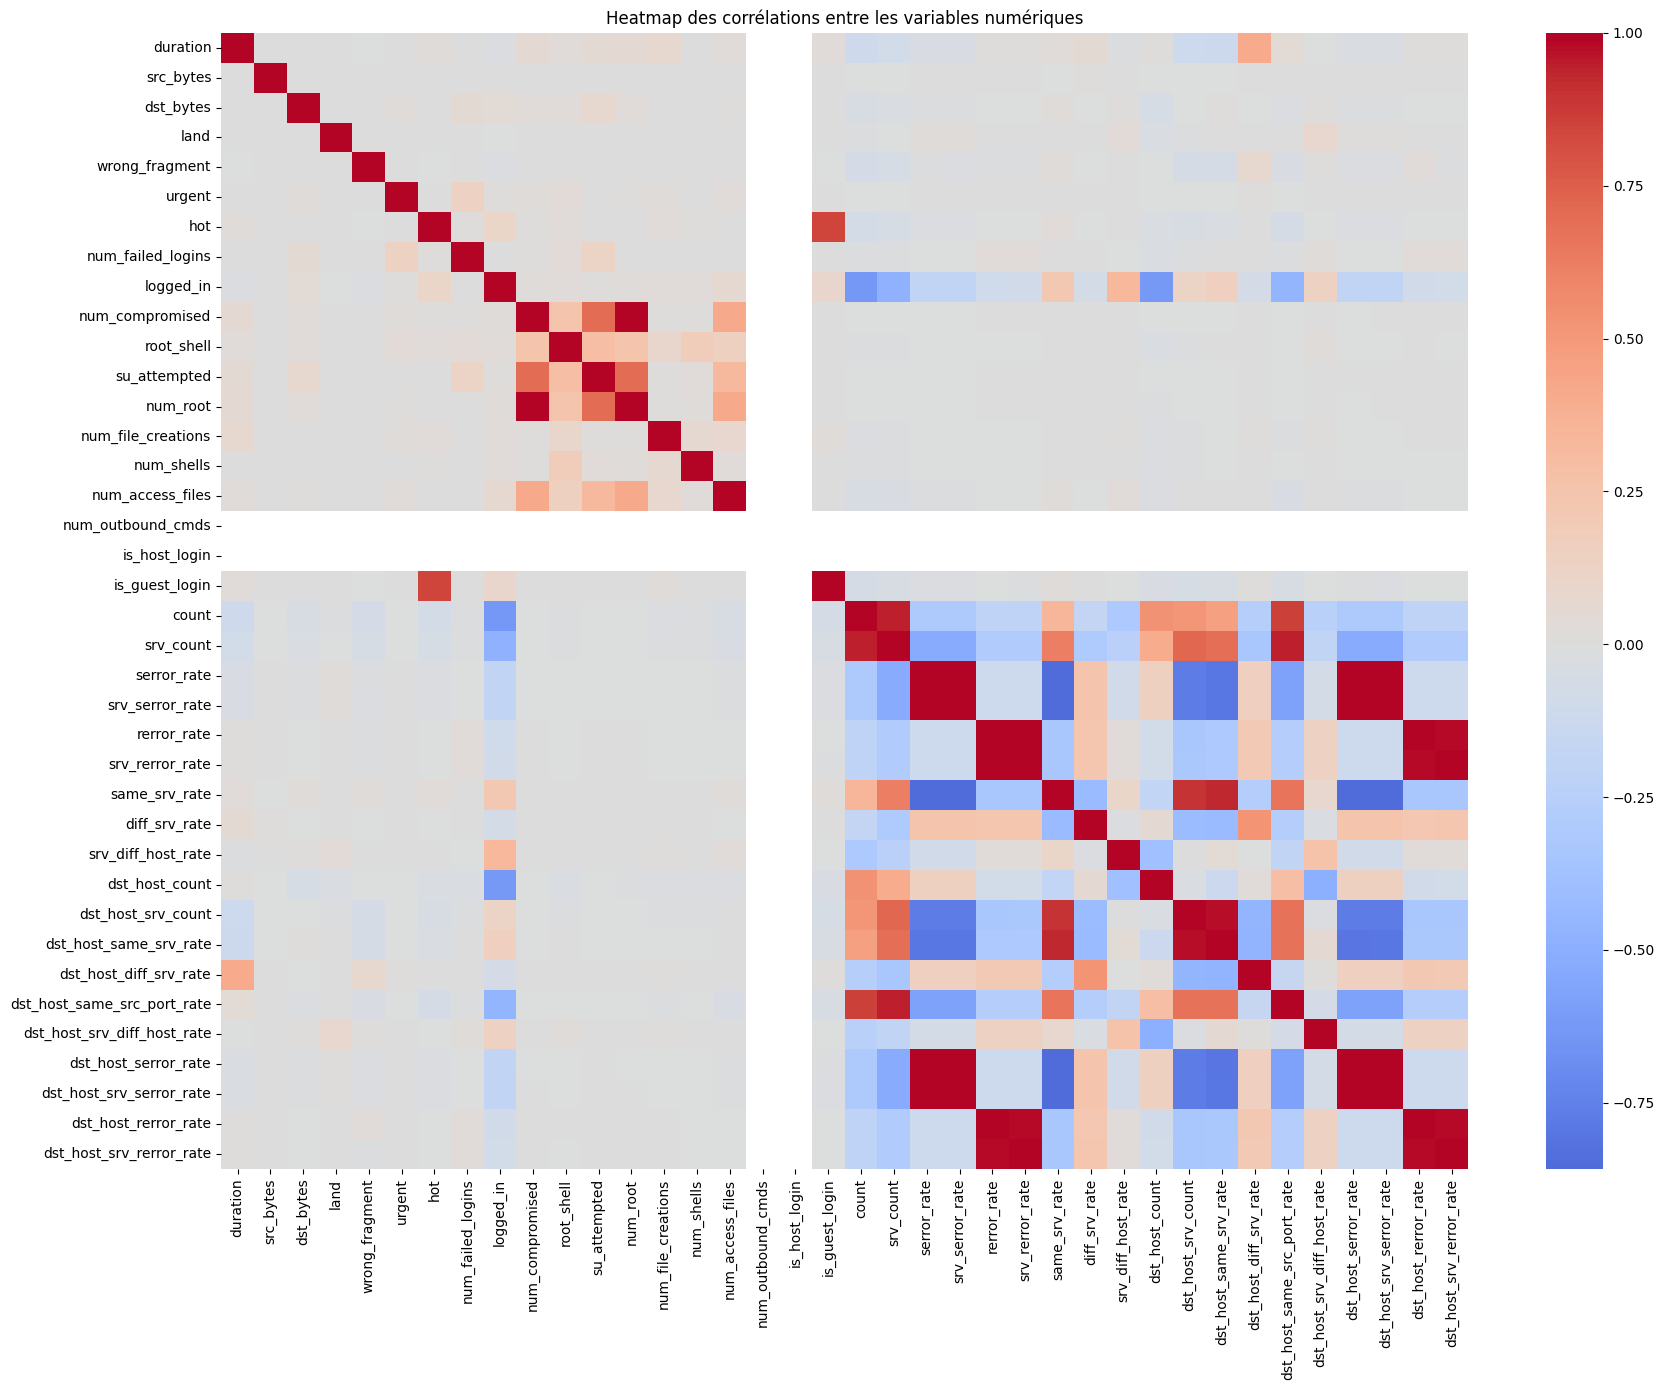

In [ ]:
# Calculer la matrice de corrélation pour les colonnes numériques
corr_matrix = dataset.corr(numeric_only=True)

# Afficher la heatmap des corrélations
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt=".2f")
plt.title("Heatmap des corrélations entre les variables numériques")
plt.tight_layout()
plt.show()

In [ ]:
# Répartition des types d'attaques (Attack Type)
print("Répartition des types d'attaques :")
display(dataset['Attack Type'].value_counts(normalize=True).rename('proportion').to_frame().join(dataset['Attack Type'].value_counts().rename('count')))

# Répartition des cibles (target)
print("\nRépartition des cibles (target) :")
display(dataset['target'].value_counts(normalize=True).rename('proportion').to_frame().join(dataset['target'].value_counts().rename('count')))

# Identifier les attaques les plus fréquentes
top_attack = dataset['Attack Type'].value_counts().idxmax()
print(f"\nCaractéristiques des attaques les plus fréquentes (Attack Type = {top_attack}):")
top_attack_df = dataset[dataset['Attack Type'] == top_attack]

# Protocole le plus fréquent
proto = top_attack_df['protocol_type'].value_counts().idxmax()
print(f"Protocole le plus fréquent : {proto}")

# Service le plus fréquent
service = top_attack_df['service'].value_counts().idxmax()
print(f"Service le plus fréquent : {service}")

# Flag le plus fréquent
flag = top_attack_df['flag'].value_counts().idxmax()
print(f"Flag le plus fréquent : {flag}")

# Affichage détaillé
print("\nDistribution des protocoles, services et flags pour l'attaque la plus fréquente :")
display(top_attack_df[['protocol_type', 'service', 'flag']].apply(pd.Series.value_counts).fillna(0))

Répartition des types d'attaques :


,proportion,count
Attack Type,,
dos,0.792391,391458
normal,0.196911,97278
probe,0.008313,4107
r2l,0.002279,1126
u2r,0.000105,52



Répartition des cibles (target) :


,proportion,count
target,,
smurf.,0.568377,280790
neptune.,0.216997,107201
normal.,0.196911,97278
back.,0.004459,2203
satan.,0.003216,1589
ipsweep.,0.002524,1247
portsweep.,0.002105,1040
warezclient.,0.002065,1020
teardrop.,0.001982,979



Caractéristiques des attaques les plus fréquentes (Attack Type = dos):
Protocole le plus fréquent : icmp
Service le plus fréquent : ecr_i
Flag le plus fréquent : SF

Distribution des protocoles, services et flags pour l'attaque la plus fréquente :


,protocol_type,service,flag
REJ,0.0,0.0,20002.0
RSTO,0.0,0.0,455.0
RSTR,0.0,0.0,91.0
S0,0.0,0.0,86765.0
S1,0.0,0.0,2.0
...,...,...,...
udp,979.0,0.0,0.0
uucp,0.0,104.0,0.0
uucp_path,0.0,105.0,0.0
vmnet,0.0,101.0,0.0


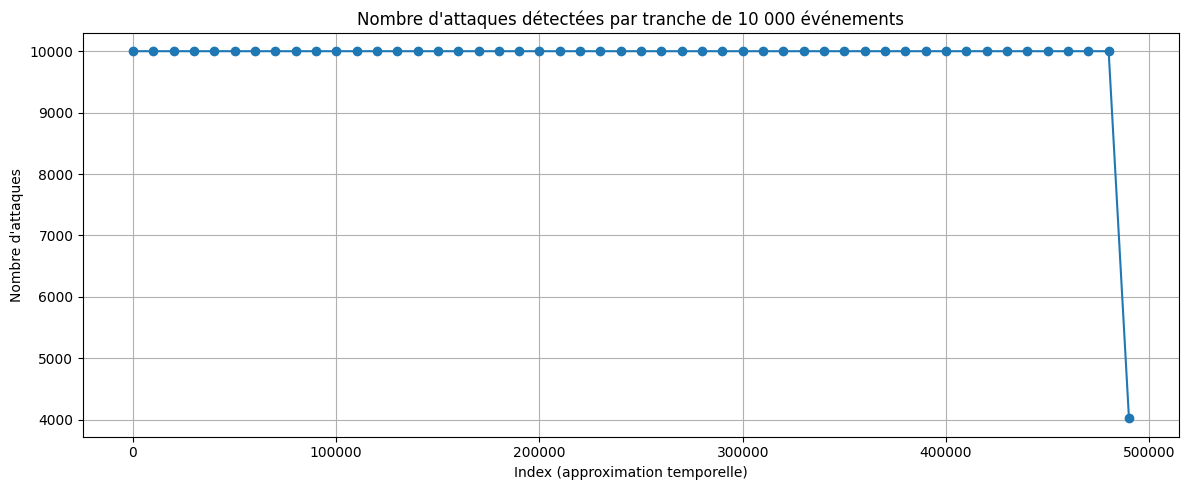

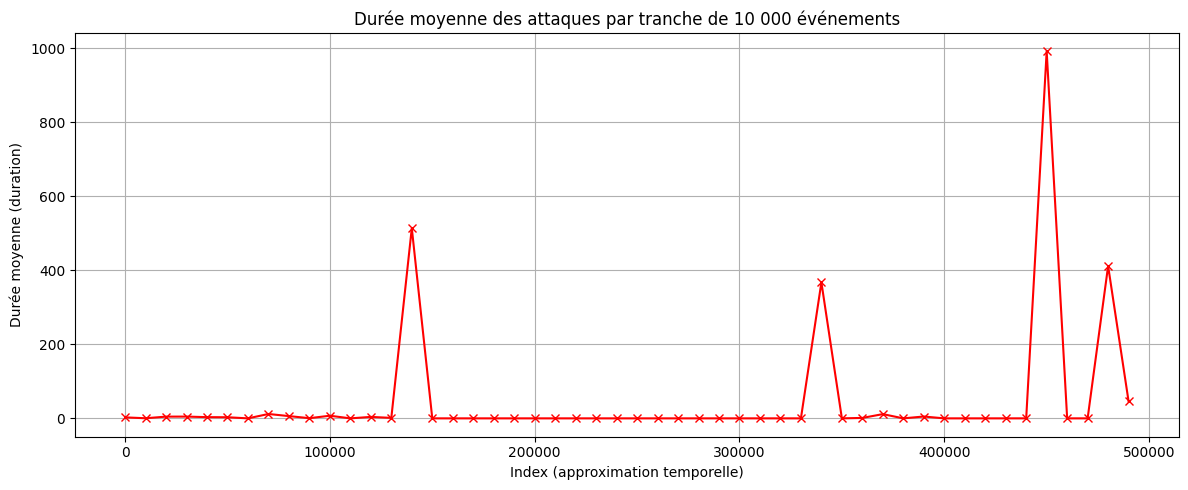

In [ ]:
# Supposons que chaque ligne représente un événement dans l'ordre chronologique
# On crée une colonne "index_time" représentant le temps fictif (ordre d'arrivée)
dataset['index_time'] = dataset.index

# Calculer le nombre d'attaques par tranche de temps (par exemple, par tranche de 10 000 événements)
window_size = 10000
dataset['is_attack'] = (dataset['Attack Type'] != 0).astype(int)
attack_counts = dataset.groupby(dataset['index_time'] // window_size)['is_attack'].sum()

plt.figure(figsize=(12, 5))
plt.plot(attack_counts.index * window_size, attack_counts.values, marker='o')
plt.title("Nombre d'attaques détectées par tranche de 10 000 événements")
plt.xlabel("Index (approximation temporelle)")
plt.ylabel("Nombre d'attaques")
plt.grid(True)
plt.tight_layout()
plt.show()

# Analyse de la durée moyenne des attaques par tranche
attack_duration = dataset[dataset['is_attack'] == 1].groupby(dataset['index_time'] // window_size)['duration'].mean()
plt.figure(figsize=(12, 5))
plt.plot(attack_duration.index * window_size, attack_duration.values, marker='x', color='red')
plt.title("Durée moyenne des attaques par tranche de 10 000 événements")
plt.xlabel("Index (approximation temporelle)")
plt.ylabel("Durée moyenne (duration)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Encoder les colonnes catégoriques
dataset['Attack Type'] = dataset['Attack Type'].astype('category').cat.codes
categorical_columns = dataset.select_dtypes(include=['object']).columns
for col in categorical_columns:
    dataset[col] = dataset[col].astype('category').cat.codes

# Séparer les caractéristiques et la cible
X = dataset.drop(columns=['target', 'Attack Type'])
y = dataset['Attack Type']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraîner un modèle Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Évaluer le modèle
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

conf_matrix, class_report

(array([[117394,      0,      0,      0,      0],
        [     0,  29186,      3,      3,      0],
        [     0,     10,   1245,      0,      0],
        [     0,     10,      0,    338,      1],
        [     0,      5,      0,      0,     12]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00    117394\n           1       1.00      1.00      1.00     29192\n           2       1.00      0.99      0.99      1255\n           3       0.99      0.97      0.98       349\n           4       0.92      0.71      0.80        17\n\n    accuracy                           1.00    148207\n   macro avg       0.98      0.93      0.95    148207\nweighted avg       1.00      1.00      1.00    148207\n')

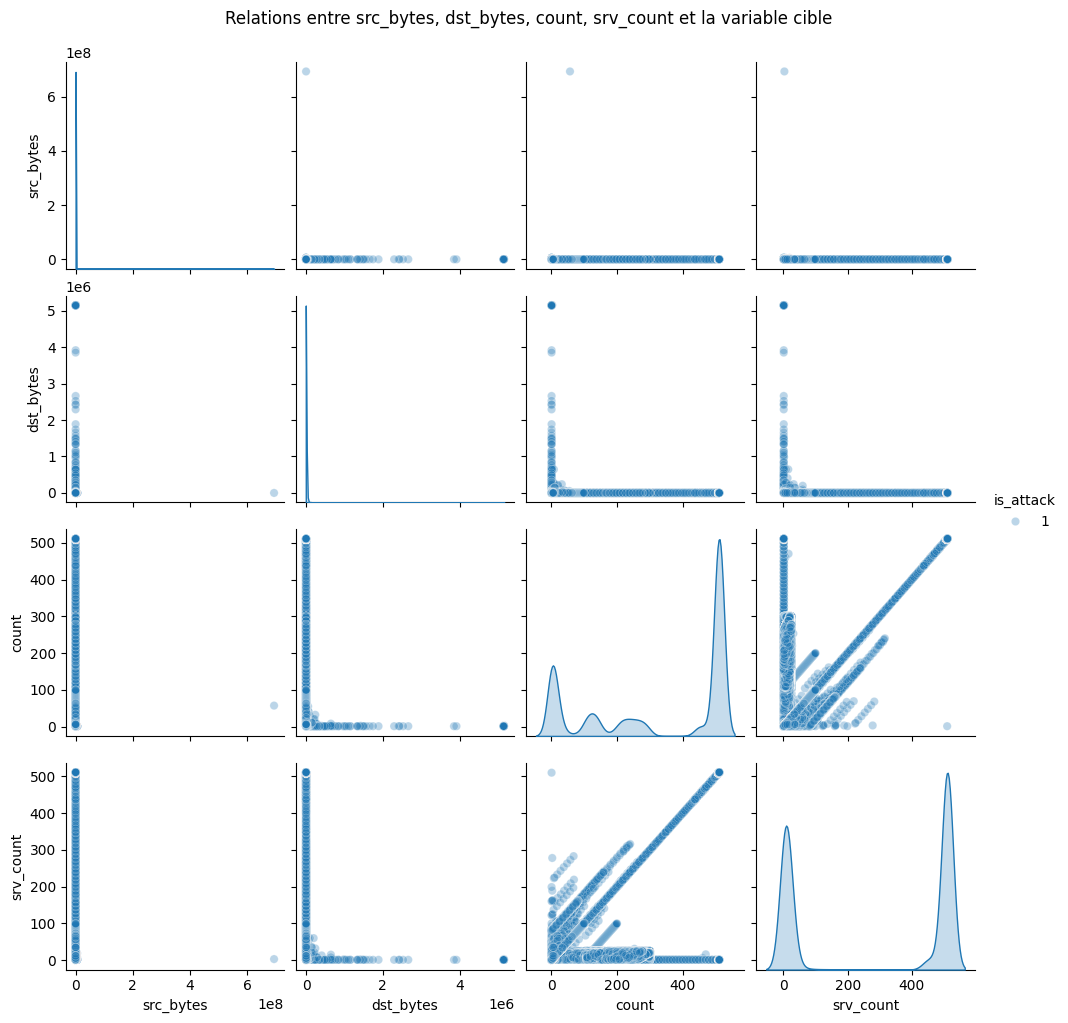

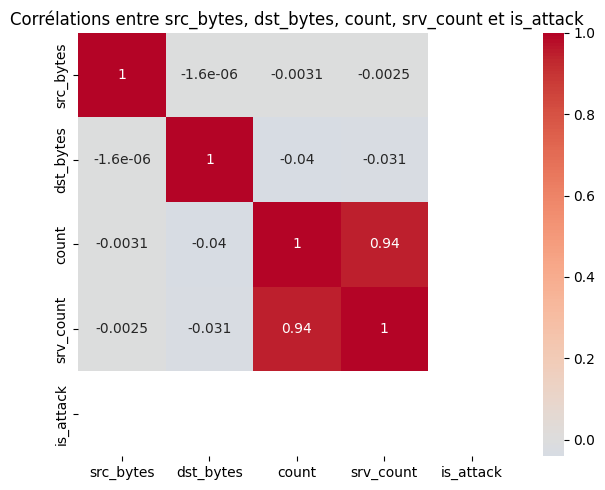

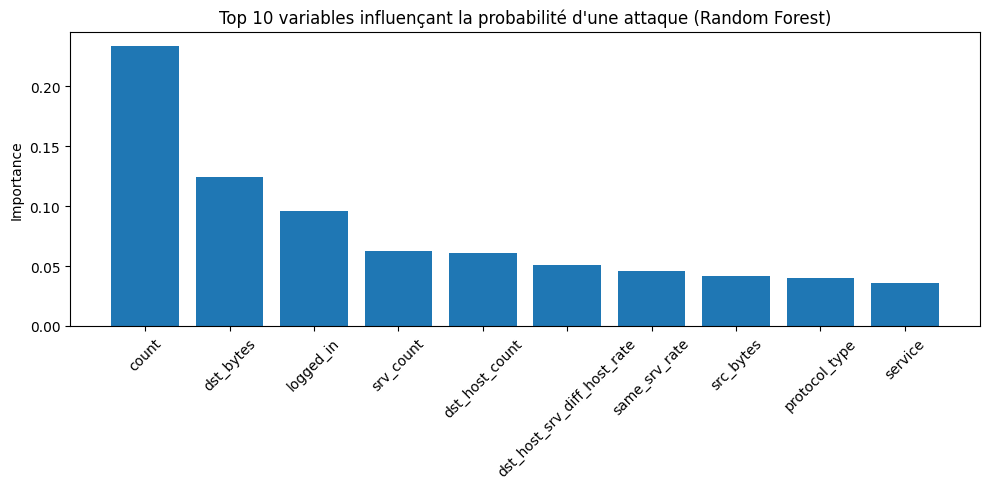

Top 10 variables les plus importantes pour la détection d'une attaque :
1. count (importance: 0.234)
2. dst_bytes (importance: 0.124)
3. logged_in (importance: 0.096)
4. srv_count (importance: 0.063)
5. dst_host_count (importance: 0.061)
6. dst_host_srv_diff_host_rate (importance: 0.051)
7. same_srv_rate (importance: 0.046)
8. src_bytes (importance: 0.041)
9. protocol_type (importance: 0.040)
10. service (importance: 0.036)


In [ ]:
# Analyse des relations entre src_bytes, dst_bytes, count, srv_count
cols_to_plot = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'is_attack']

# Pairplot pour visualiser les relations et la séparation attaque/non-attaque
sns.pairplot(dataset[cols_to_plot], hue='is_attack', plot_kws={'alpha': 0.3})
plt.suptitle("Relations entre src_bytes, dst_bytes, count, srv_count et la variable cible", y=1.02)
plt.show()

# Matrice de corrélation centrée sur la variable cible
corr = dataset[cols_to_plot].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Corrélations entre src_bytes, dst_bytes, count, srv_count et is_attack")
plt.tight_layout()
plt.show()

# Importance des variables selon le modèle Random Forest déjà entraîné
importances = model.feature_importances_
features = X_train.columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 5))
plt.title("Top 10 variables influençant la probabilité d'une attaque (Random Forest)")
top_n = 10
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), features[indices[:top_n]], rotation=45)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 variables les plus importantes pour la détection d'une attaque :")
for i in range(top_n):
    print(f"{i+1}. {features[indices[i]]} (importance: {importances[indices[i]]:.3f})")

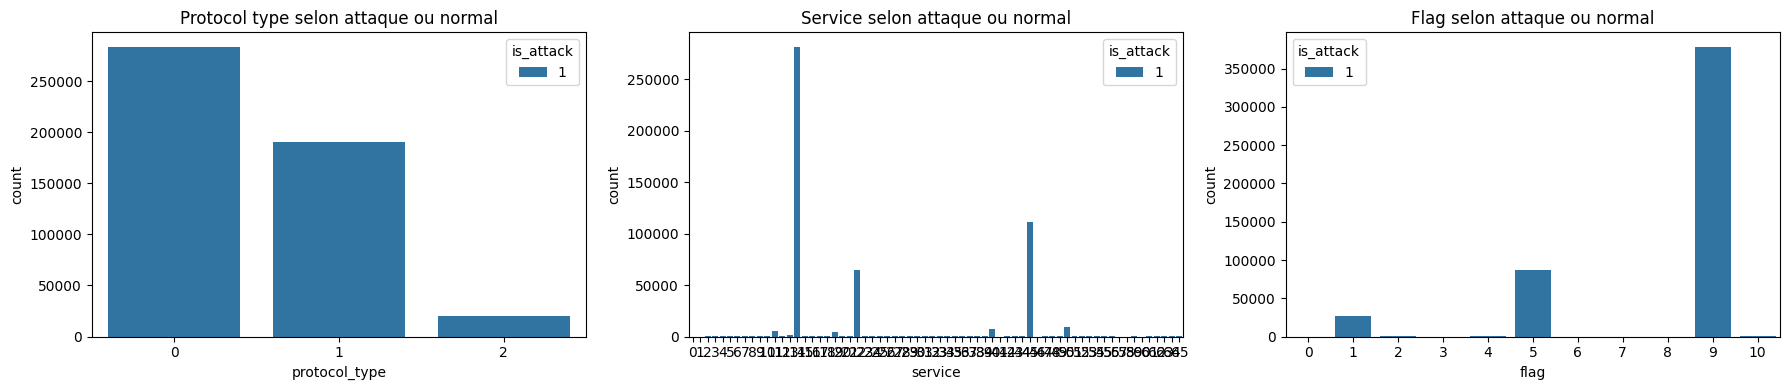

is_attack                     1
src_bytes   count  4.940210e+05
            mean   3.025610e+03
            std    9.882181e+05
            min    0.000000e+00
            25%    4.500000e+01
            50%    5.200000e+02
            75%    1.032000e+03
            max    6.933756e+08
dst_bytes   count  4.940210e+05
            mean   8.685324e+02
            std    3.304000e+04
            min    0.000000e+00
            25%    0.000000e+00
            50%    0.000000e+00
            75%    0.000000e+00
            max    5.155468e+06
count       count  4.940210e+05
            mean   3.322857e+02
            std    2.131474e+02
            min    0.000000e+00
            25%    1.170000e+02
            50%    5.100000e+02
            75%    5.110000e+02
            max    5.110000e+02
srv_count   count  4.940210e+05
            mean   2.929066e+02
            std    2.463228e+02
            min    0.000000e+00
            25%    1.000000e+01
            50%    5.100000e+02
            75%    5.110000e+02
            max    5.110000e+02
serror_rate count  4.940210e+05
            mean   1.766867e-01
            std    3.807170e-01
            min    0.000000e+00
            25%    0.000000e+00
            50%    0.000000e+00
            75%    0.000000e+00
            max    1.000000e+00
rerror_rate count  4.940210e+05
            mean   5.743341e-02
            std    2.316235e-01
            min    0.000000e+00
            25%    0.000000e+00
            50%    0.000000e+00
            75%    0.000000e+00
            max    1.000000e+00

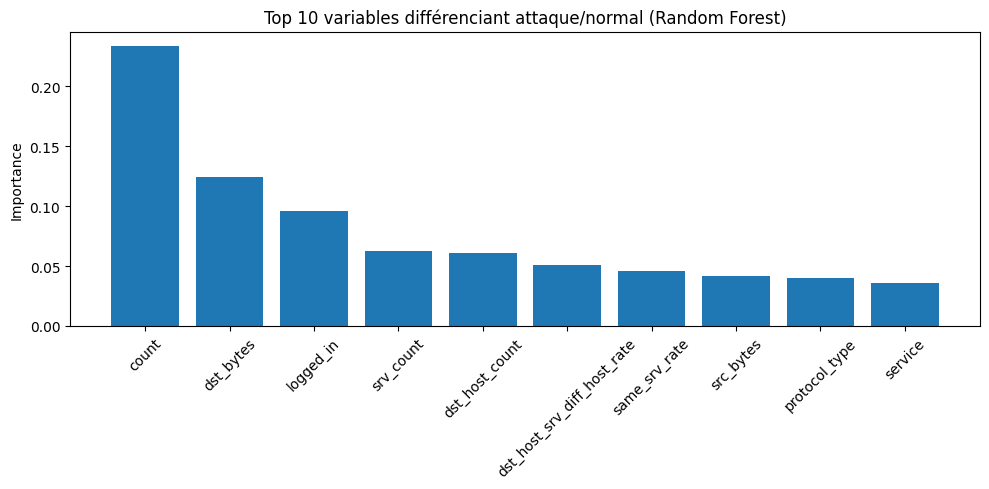

Variables les plus discriminantes pour la détection d'une attaque :
1. count (importance: 0.234)
2. dst_bytes (importance: 0.124)
3. logged_in (importance: 0.096)
4. srv_count (importance: 0.063)
5. dst_host_count (importance: 0.061)
6. dst_host_srv_diff_host_rate (importance: 0.051)
7. same_srv_rate (importance: 0.046)
8. src_bytes (importance: 0.041)
9. protocol_type (importance: 0.040)
10. service (importance: 0.036)


In [ ]:
# Étude des caractéristiques des attaques vs comportements normaux

# 1. Analyse des distributions pour protocol_type, service, flag selon la variable cible
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x='protocol_type', hue='is_attack', data=dataset, ax=axes[0])
axes[0].set_title("Protocol type selon attaque ou normal")
sns.countplot(x='service', hue='is_attack', data=dataset, ax=axes[1])
axes[1].set_title("Service selon attaque ou normal")
sns.countplot(x='flag', hue='is_attack', data=dataset, ax=axes[2])
axes[2].set_title("Flag selon attaque ou normal")
plt.tight_layout()
plt.show()

# 2. Statistiques descriptives pour quelques variables continues selon attaque ou normal
cols_to_compare = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'rerror_rate']
display(dataset.groupby('is_attack')[cols_to_compare].describe().T)

# 3. Importance des variables selon le modèle Random Forest déjà entraîné
importances = model.feature_importances_
features = X_train.columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 5))
plt.title("Top 10 variables différenciant attaque/normal (Random Forest)")
top_n = 10
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), features[indices[:top_n]], rotation=45)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Variables les plus discriminantes pour la détection d'une attaque :")
for i in range(top_n):
    print(f"{i+1}. {features[indices[i]]} (importance: {importances[indices[i]]:.3f})")

,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate
count,494021.000000,494021.000000,494021.000000,494021.000000
mean,0.176687,0.176609,0.057433,0.057719
std,0.380717,0.381017,0.231623,0.232147
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


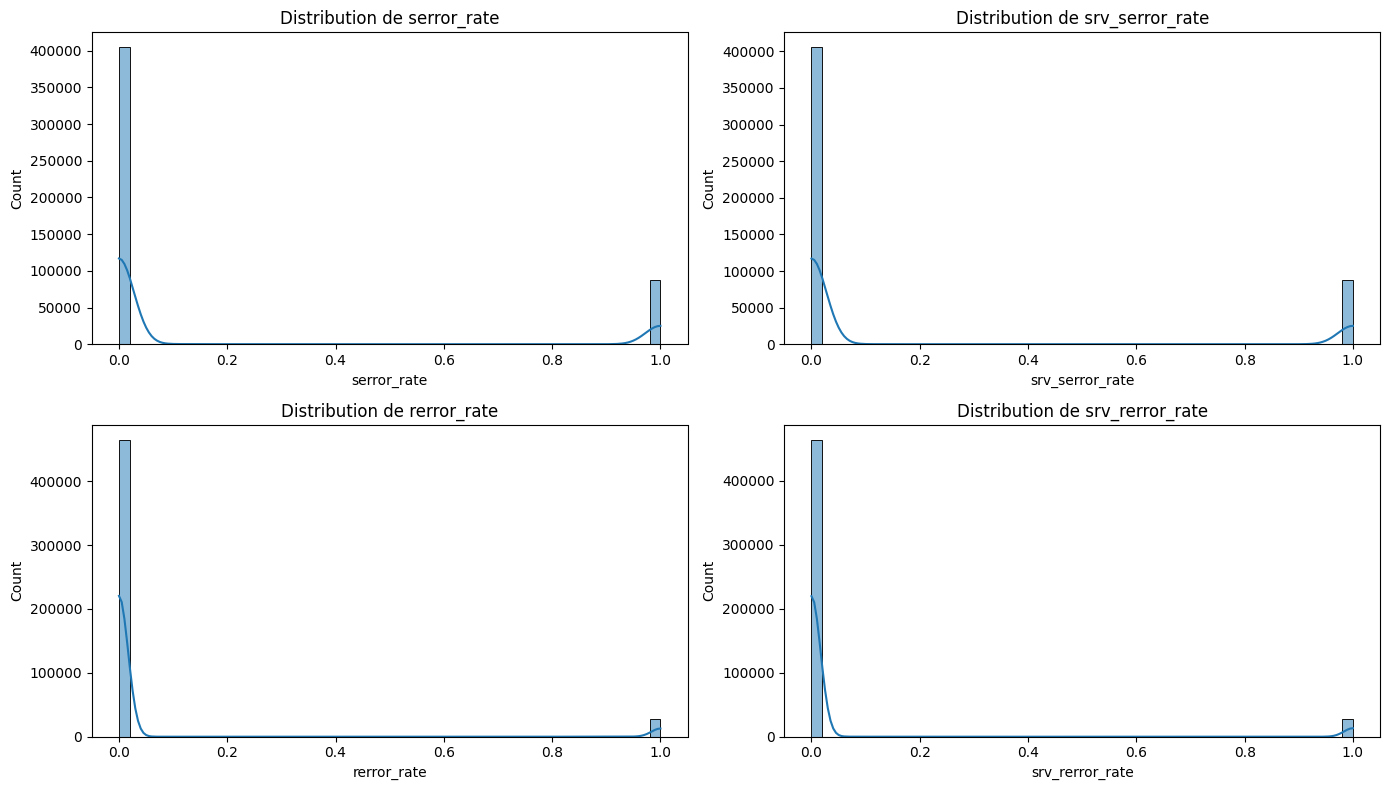

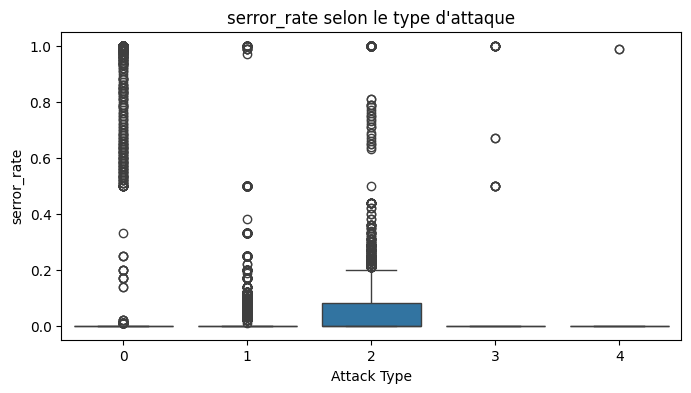

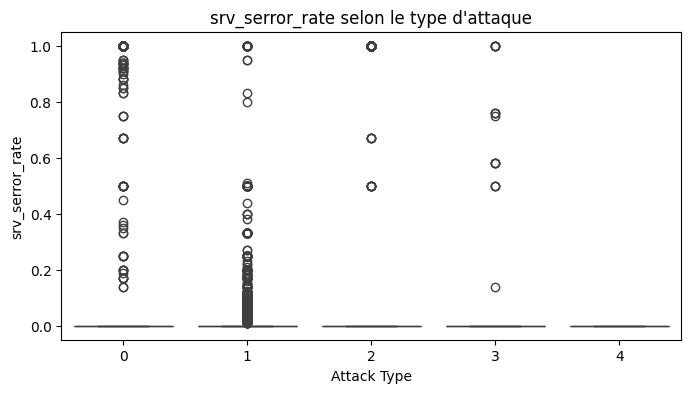

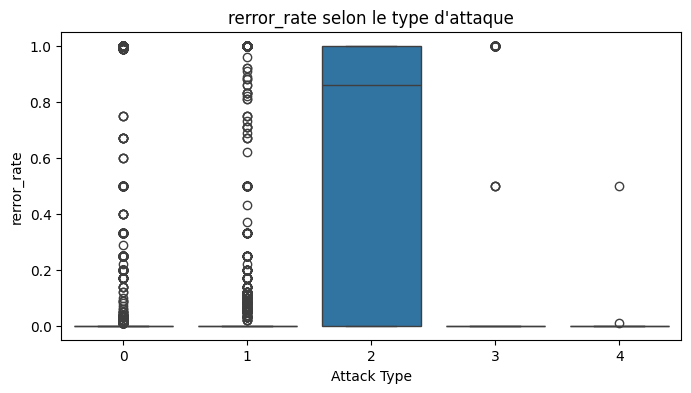

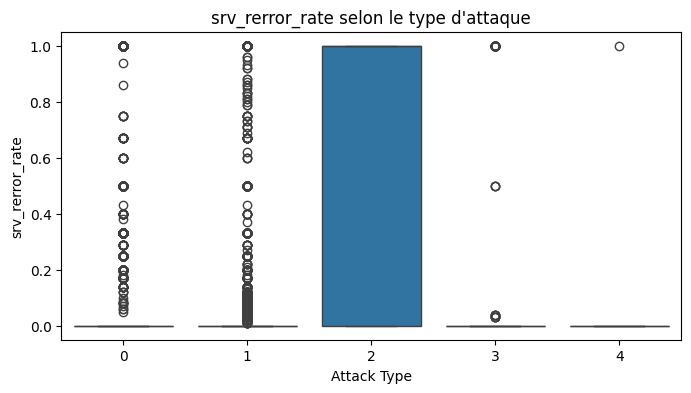

,Attack Type
Attack Type,1.000000
rerror_rate,0.077320
srv_rerror_rate,0.076864
srv_serror_rate,-0.217263
serror_rate,-0.217871


In [ ]:
# Sélection des colonnes liées aux erreurs
error_cols = ['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate']

# Statistiques descriptives pour chaque type d'erreur
display(dataset[error_cols].describe())

# Distribution des taux d'erreur pour chaque type
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), error_cols):
    sns.histplot(dataset[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.show()

# Analyse par type d'attaque
for col in error_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Attack Type', y=col, data=dataset)
    plt.title(f"{col} selon le type d'attaque")
    plt.show()

# Corrélation entre les taux d'erreur et la variable cible
corrs = dataset[error_cols + ['Attack Type']].corr()
display(corrs['Attack Type'].sort_values(ascending=False))

,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count
count,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,0.791547,0.020982,0.028997,232.470778,188.665670
std,0.388189,0.082205,0.142397,64.745380,106.040437
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,255.000000,46.000000
50%,1.000000,0.000000,0.000000,255.000000,255.000000
75%,1.000000,0.000000,0.000000,255.000000,255.000000
max,1.000000,1.000000,1.000000,255.000000,255.000000


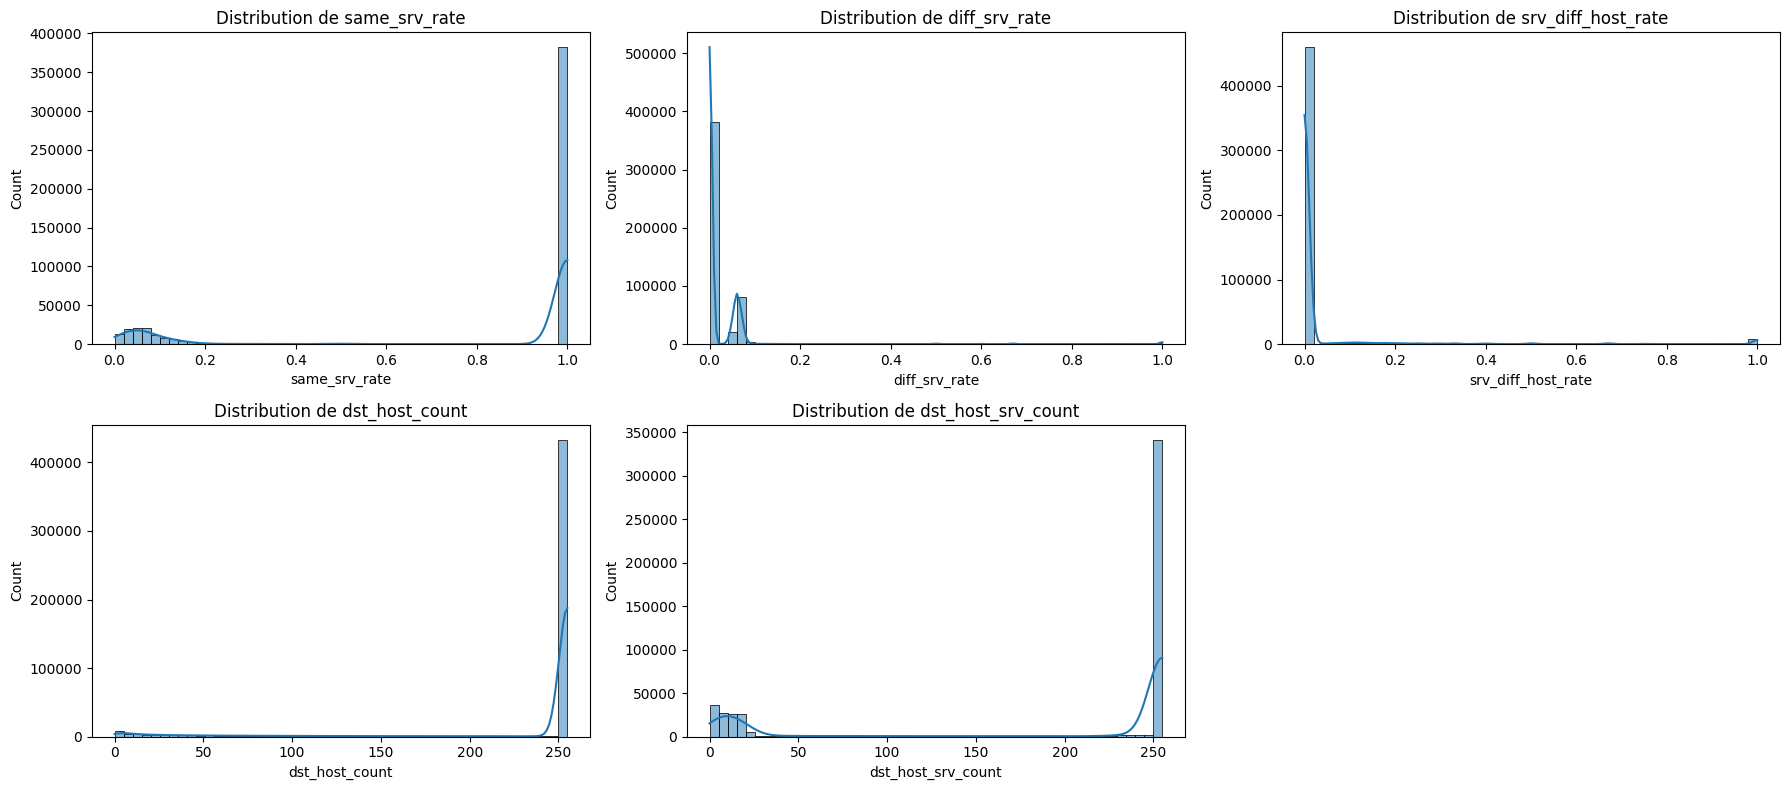

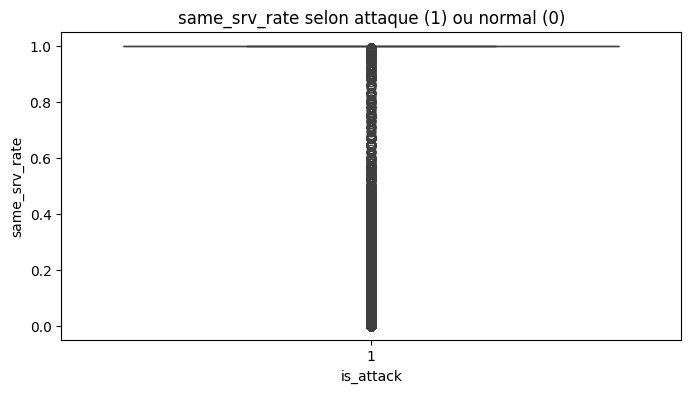

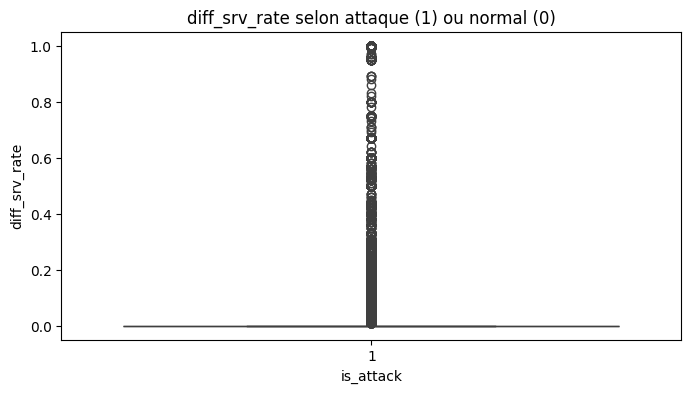

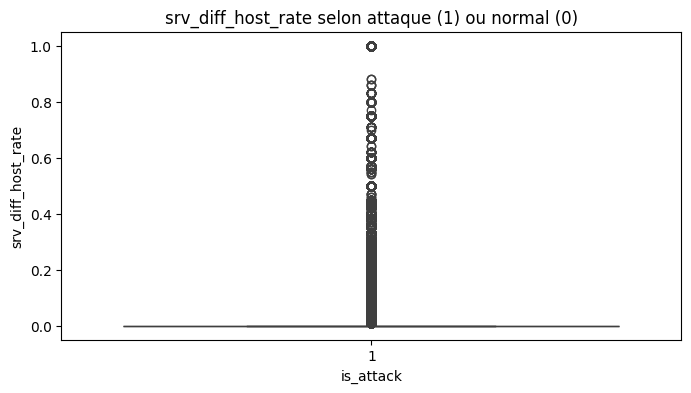

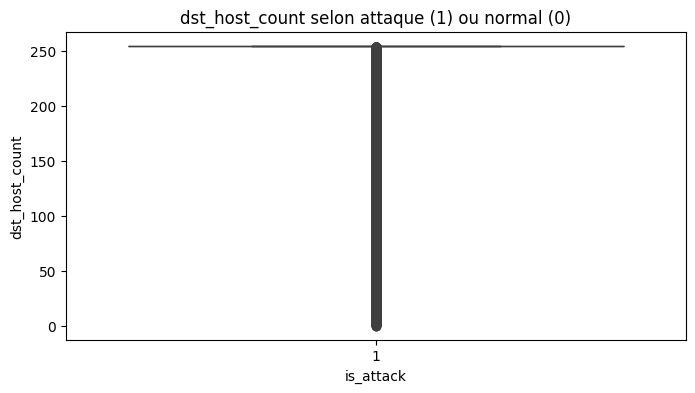

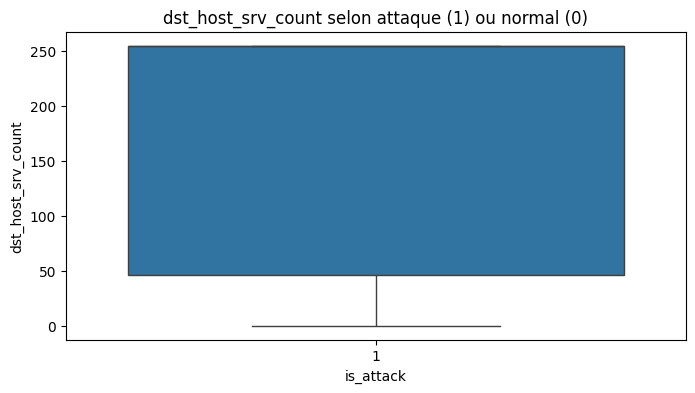

,is_attack
same_srv_rate,NaN
diff_srv_rate,NaN
srv_diff_host_rate,NaN
dst_host_count,NaN
dst_host_srv_count,NaN
is_attack,NaN


In [ ]:
cols_network = ['same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count']

# Statistiques descriptives
display(dataset[cols_network].describe())

# Visualisation des distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(cols_network):
    ax = axes.flatten()[i]
    sns.histplot(dataset[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

# Analyse selon la variable cible (is_attack)
for col in cols_network:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='is_attack', y=col, data=dataset)
    plt.title(f"{col} selon attaque (1) ou normal (0)")
    plt.xlabel("is_attack")
    plt.ylabel(col)
    plt.show()

# Corrélations entre ces variables et la cible
corrs = dataset[cols_network + ['is_attack']].corr()
display(corrs['is_attack'].sort_values(ascending=False))

In [ ]:
# Segmentation des données par type d'attaque
attack_types = dataset['Attack Type'].unique()
attack_segments = {}

for attack in attack_types:
    segment = dataset[dataset['Attack Type'] == attack]
    attack_segments[attack] = segment
    print(f"Type d'attaque {attack} : {len(segment)} échantillons")
    display(segment.describe())

# Exemple d'accès à un segment spécifique :
# attack_segments[0]  # Segment pour le type d'attaque 0 (normal)

Type d'attaque 1 : 97278 échantillons


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type,index_time,is_attack
count,97278.000000,97278.000000,97278.000000,97278.000000,9.727800e+04,9.727800e+04,97278.000000,97278.0,97278.000000,97278.000000,...,97278.000000,97278.000000,97278.000000,97278.000000,97278.000000,97278.000000,97278.0,97278.0,97278.000000,97278.0
mean,216.657322,1.183896,27.010300,8.550073,1.157048e+03,3.384651e+03,0.000010,0.0,0.000031,0.044512,...,0.133952,0.024123,0.002121,0.001068,0.057717,0.055830,11.0,1.0,161283.406587,1.0
std,1359.213469,0.420191,11.575851,1.835263,3.422612e+04,3.757820e+04,0.003206,0.0,0.009619,0.858464,...,0.280805,0.049505,0.029422,0.015724,0.224995,0.218892,0.0,0.0,174041.466166,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0,1.0,0.000000,1.0
25%,0.000000,1.000000,22.000000,9.000000,1.470000e+02,1.360000e+02,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0,1.0,28303.250000,1.0
50%,0.000000,1.000000,22.000000,9.000000,2.310000e+02,4.210000e+02,0.000000,0.0,0.000000,0.000000,...,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,11.0,1.0,83723.500000,1.0
75%,0.000000,1.000000,22.000000,9.000000,3.130000e+02,2.121000e+03,0.000000,0.0,0.000000,0.000000,...,0.070000,0.030000,0.000000,0.000000,0.000000,0.000000,11.0,1.0,344936.750000,1.0
max,58329.000000,2.000000,61.000000,9.000000,2.194619e+06,5.134218e+06,1.000000,0.0,3.000000,30.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.0,1.0,494020.000000,1.0


Type d'attaque 4 : 52 échantillons


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type,index_time,is_attack
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0,52.0,52.000000,52.000000,...,52.000000,52.000000,52.0,52.000000,52.000000,52.000000,52.000000,52.0,52.000000,52.0
mean,80.942308,1.057692,44.346154,8.865385,906.230769,5141.961538,0.0,0.0,0.019231,1.403846,...,0.568269,0.081154,0.0,0.004808,0.039615,0.019038,5.557692,4.0,256092.365385,1.0
std,120.510908,0.235435,16.841690,0.970725,1188.259720,10081.513629,0.0,0.0,0.138675,1.537245,...,0.428988,0.213143,0.0,0.034669,0.140893,0.052141,6.033935,0.0,169288.702307,0.0
min,0.000000,1.000000,18.000000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,4.0,744.000000,1.0
25%,0.000000,1.000000,19.000000,9.000000,4.000000,1753.000000,0.0,0.0,0.000000,0.000000,...,0.135000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,4.0,141512.750000,1.0
50%,46.000000,1.000000,56.000000,9.000000,273.000000,2907.000000,0.0,0.0,0.000000,1.000000,...,0.500000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,4.0,149010.500000,1.0
75%,105.500000,1.000000,56.000000,9.000000,1567.000000,5020.000000,0.0,0.0,0.000000,3.000000,...,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,8.250000,4.0,451932.250000,1.0
max,708.000000,2.000000,56.000000,9.000000,6274.000000,70529.000000,0.0,0.0,1.000000,5.000000,...,1.000000,1.000000,0.0,0.250000,0.730000,0.250000,16.000000,4.0,485181.000000,1.0


Type d'attaque 0 : 391458 échantillons


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type,index_time,is_attack
count,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.0,391458.000000,...,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.000000,391458.0,391458.000000,391458.0
mean,0.000725,0.284534,22.417322,7.695308,977.053753,46.330853,0.000054,0.008118,0.0,0.011048,...,0.718262,0.000179,0.221740,0.221599,0.053114,0.052542,15.435707,0.0,269550.955239,1.0
std,0.083812,0.456702,13.801379,2.275333,4033.026304,617.588069,0.007324,0.151394,0.0,0.147730,...,0.449212,0.009695,0.415295,0.415283,0.223212,0.222583,4.178305,0.0,124583.193988,0.0
min,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,7601.000000,1.0
25%,0.000000,0.000000,14.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.0,173562.250000,1.0
50%,0.000000,0.000000,14.000000,9.000000,1032.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.0,271426.500000,1.0
75%,0.000000,1.000000,45.000000,9.000000,1032.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.0,376558.750000,1.0
max,14.000000,2.000000,65.000000,9.000000,54540.000000,8315.000000,1.000000,3.000000,0.0,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000,0.0,490964.000000,1.0


Type d'attaque 3 : 1126 échantillons


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type,index_time,is_attack
count,1126.000000,1126.0,1126.000000,1126.000000,1.126000e+03,1.126000e+03,1126.0,1126.0,1126.000000,1126.000000,...,1126.000000,1126.000000,1126.000000,1126.000000,1126.000000,1126.000000,1126.000000,1126.0,1126.000000,1126.0
mean,559.752220,1.0,20.771758,8.684725,2.719726e+05,7.230494e+04,0.0,0.0,0.002664,7.389876,...,0.637309,0.091750,0.021554,0.014609,0.045178,0.041856,19.741563,3.0,135181.107460,1.0
std,2108.336967,0.0,8.304983,1.430797,1.146287e+06,5.926519e+05,0.0,0.0,0.066613,11.947360,...,0.464419,0.115805,0.088527,0.081207,0.190914,0.190847,4.542324,0.0,31143.677324,0.0
min,0.000000,1.0,18.000000,2.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.0,15699.000000,1.0
25%,0.000000,1.0,18.000000,9.000000,3.340000e+02,0.000000e+00,0.0,0.0,0.000000,0.000000,...,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,3.0,140522.250000,1.0
50%,0.000000,1.0,19.000000,9.000000,3.340000e+02,0.000000e+00,0.0,0.0,0.000000,0.000000,...,1.000000,0.070000,0.000000,0.000000,0.000000,0.000000,21.000000,3.0,142629.500000,1.0
75%,1.000000,1.0,19.000000,9.000000,1.212000e+03,2.447000e+03,0.0,0.0,0.000000,20.000000,...,1.000000,0.150000,0.000000,0.000000,0.000000,0.000000,21.000000,3.0,147084.750000,1.0
max,15168.000000,1.0,56.000000,10.000000,5.135678e+06,5.155468e+06,0.0,0.0,2.000000,28.000000,...,1.000000,1.000000,1.000000,1.000000,0.960000,0.960000,22.000000,3.0,452731.000000,1.0


Type d'attaque 2 : 4107 échantillons


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type,index_time,is_attack
count,4107.000000,4107.000000,4107.000000,4107.000000,4.107000e+03,4107.000000,4107.0,4107.0,4107.0,4107.000000,...,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.0,4107.000000,4107.0
mean,485.029949,0.740687,33.075724,4.862187,1.688327e+05,0.449233,0.0,0.0,0.0,0.000974,...,0.589576,0.189367,0.070058,0.072854,0.548300,0.563779,12.456294,2.0,159579.113221,1.0
std,3758.147991,0.535817,13.914475,3.549456,1.081948e+07,8.610619,0.0,0.0,0.0,0.031197,...,0.474631,0.309269,0.169181,0.258677,0.441584,0.495115,5.181952,0.0,124106.951748,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.0,22814.000000,1.0
25%,0.000000,0.000000,13.000000,1.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.0,82967.500000,1.0
50%,0.000000,1.000000,40.000000,4.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.810000,1.000000,15.000000,2.0,140829.000000,1.0
75%,0.000000,1.000000,45.000000,9.000000,8.000000e+00,0.000000,0.0,0.0,0.0,0.000000,...,1.000000,0.500000,0.080000,0.000000,0.970000,1.000000,17.000000,2.0,149617.500000,1.0
max,42448.000000,2.000000,65.000000,10.000000,6.933756e+08,375.000000,0.0,0.0,0.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,17.000000,2.0,485172.000000,1.0


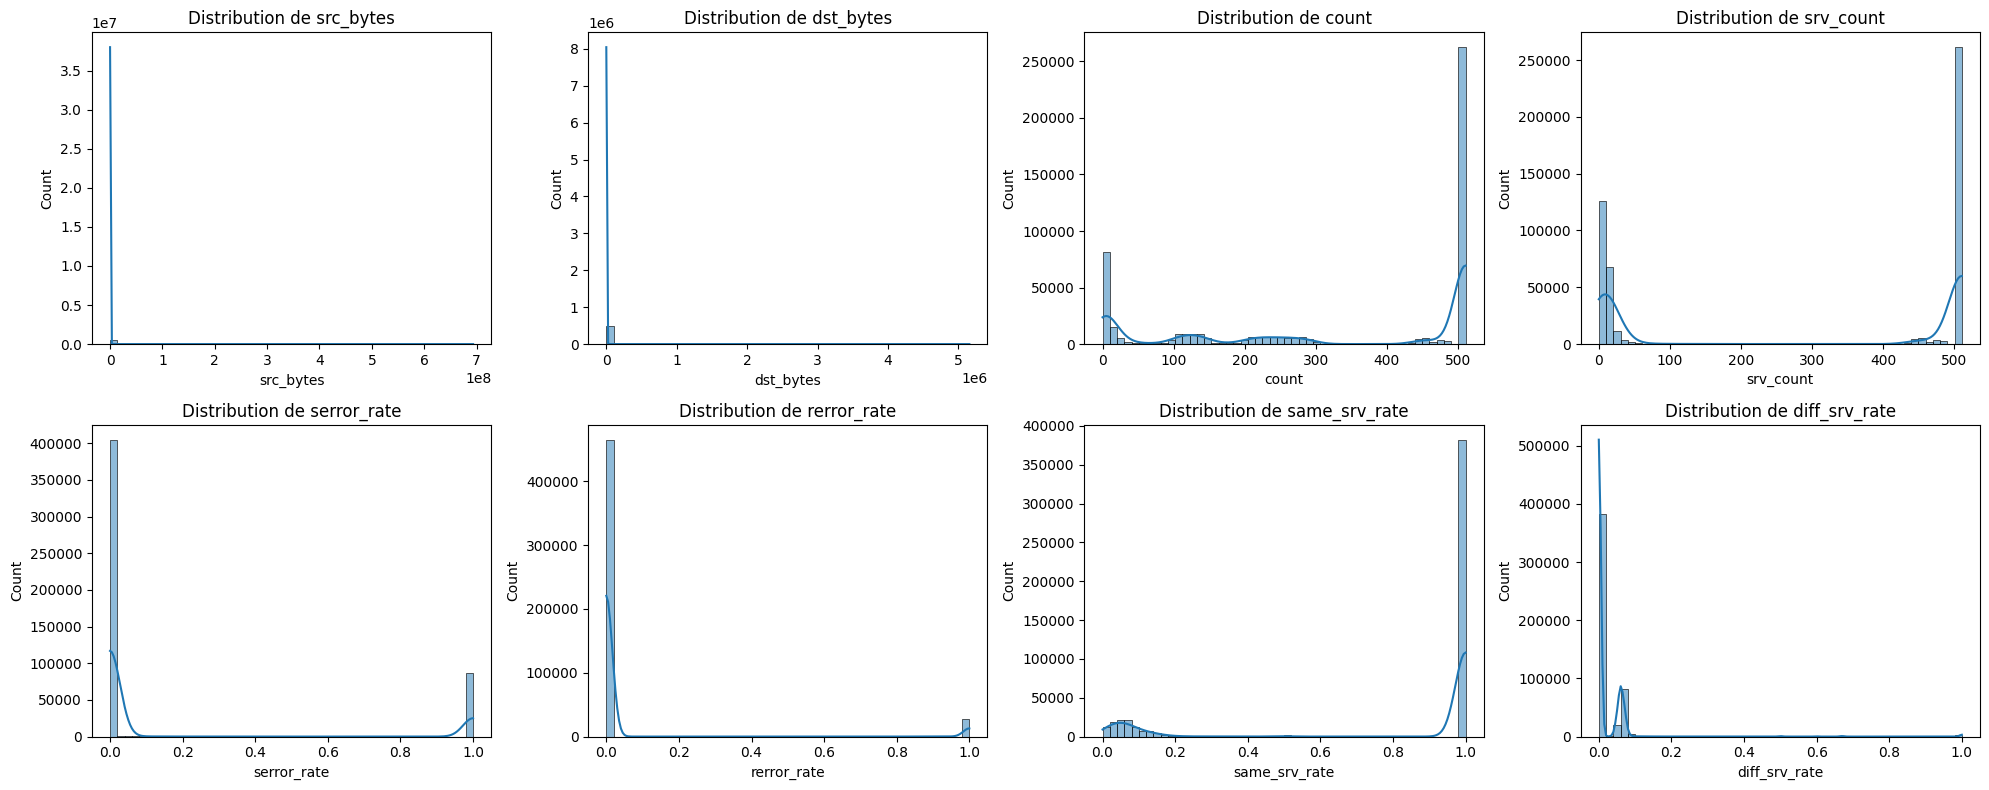

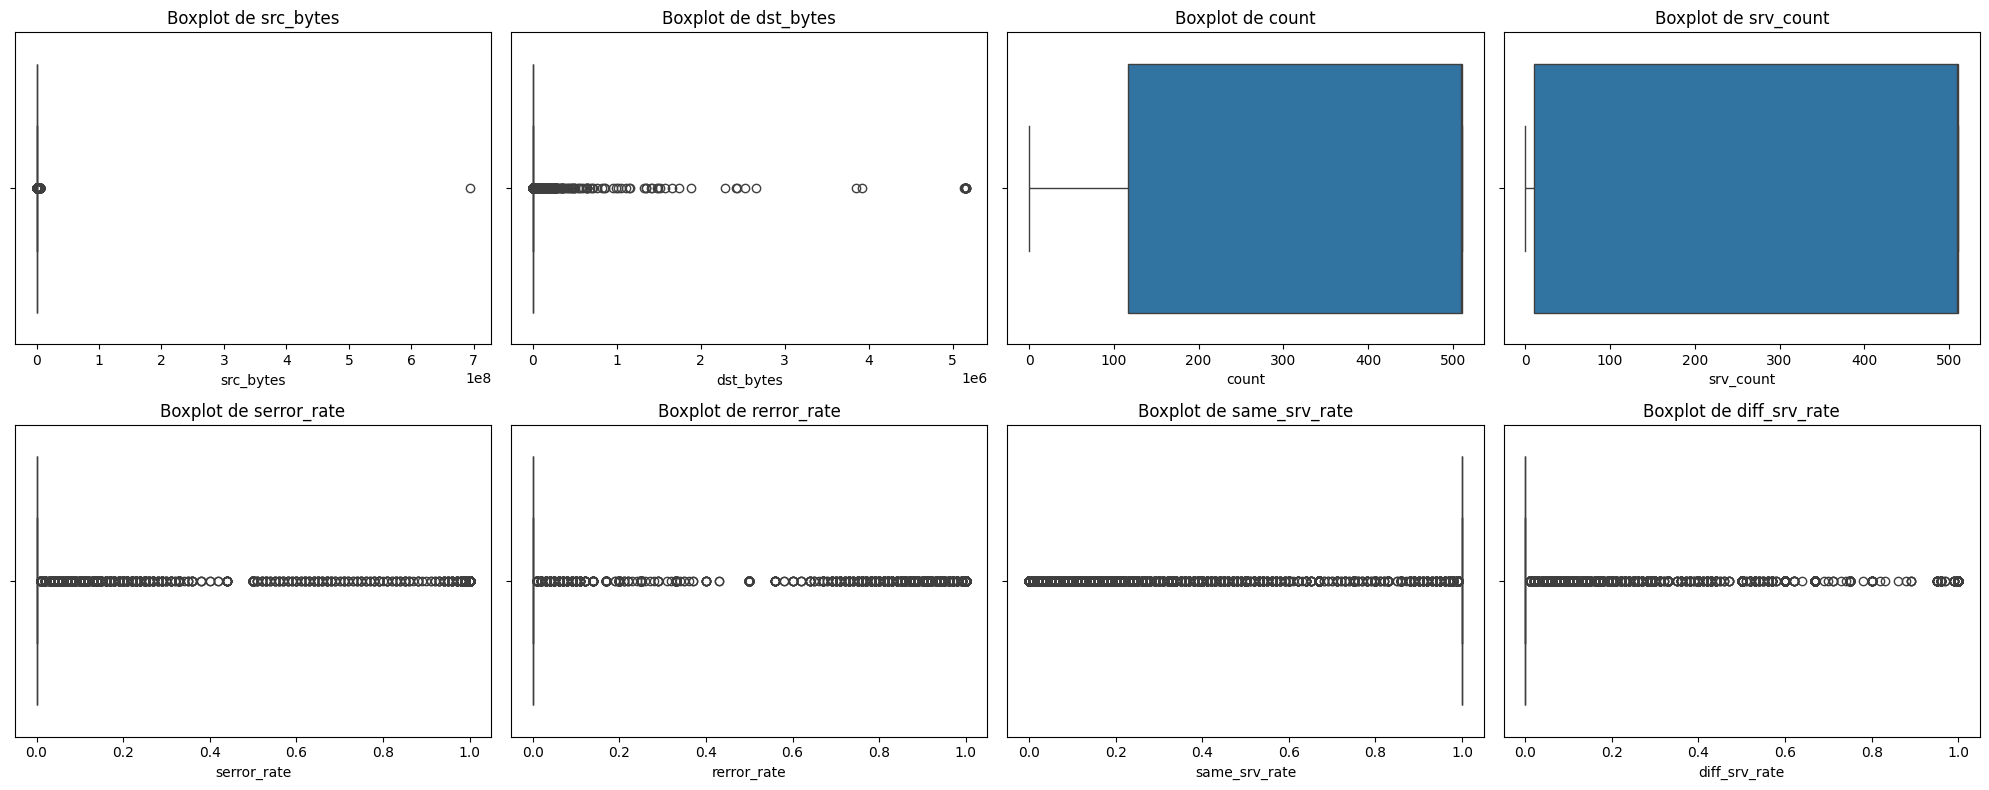

In [ ]:
# Liste des colonnes numériques à visualiser
num_cols = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate']

# Histogrammes
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(dataset[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.show()

# Box plots pour détecter les valeurs aberrantes
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=dataset[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

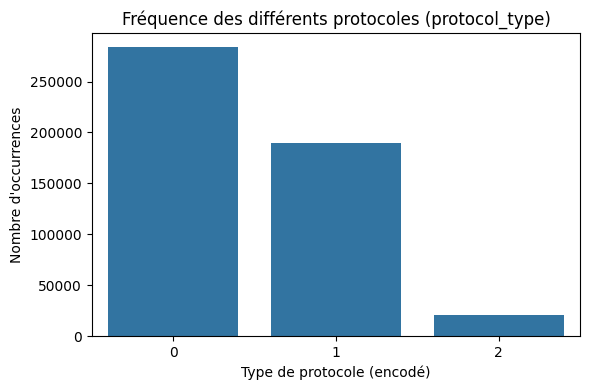

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='protocol_type', data=dataset)
plt.title("Fréquence des différents protocoles (protocol_type)")
plt.xlabel("Type de protocole (encodé)")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

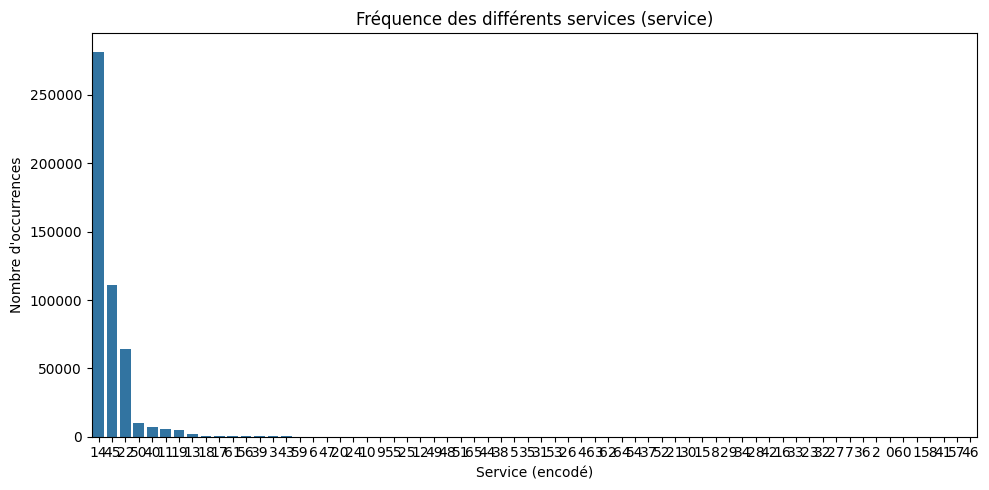

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='service', data=dataset, order=dataset['service'].value_counts().index)
plt.title("Fréquence des différents services (service)")
plt.xlabel("Service (encodé)")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

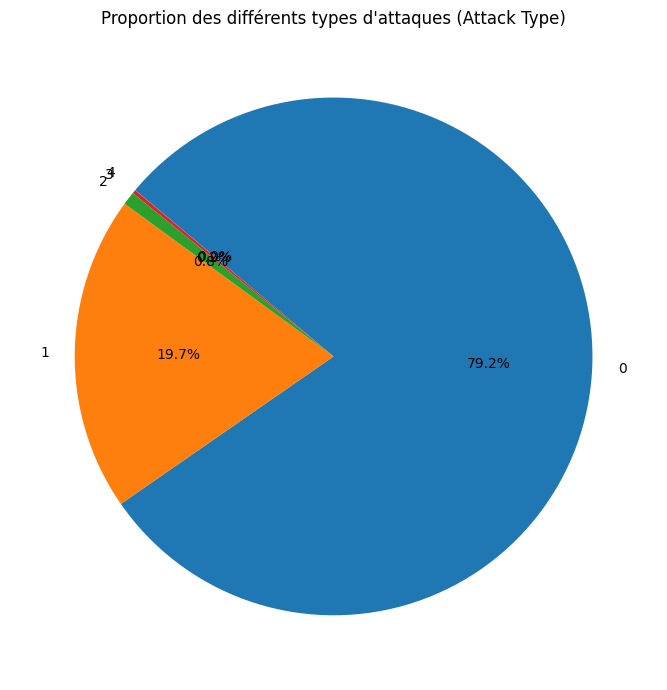

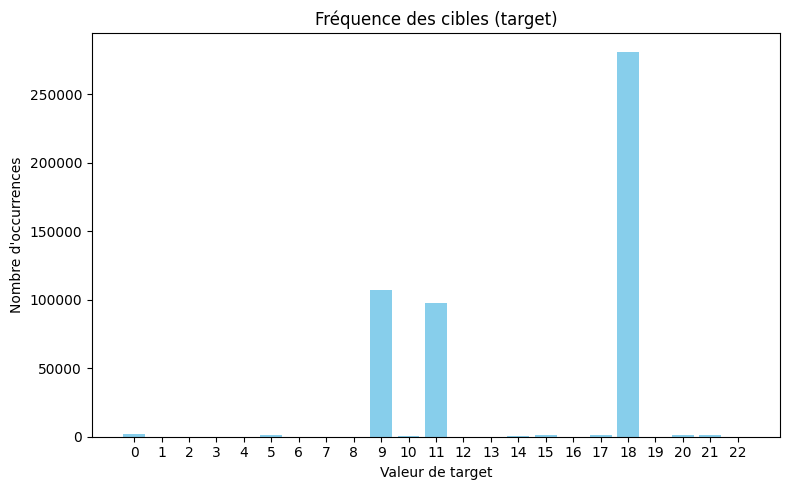

In [ ]:
# Pie chart pour la proportion des types d'attaques
attack_counts = dataset['Attack Type'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=140, counterclock=False)
plt.title("Proportion des différents types d'attaques (Attack Type)")
plt.tight_layout()
plt.show()

# Bar plot pour la fréquence des cibles (target)
target_counts = dataset['target'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(target_counts.index.astype(str), target_counts.values, color='skyblue')
plt.title("Fréquence des cibles (target)")
plt.xlabel("Valeur de target")
plt.ylabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

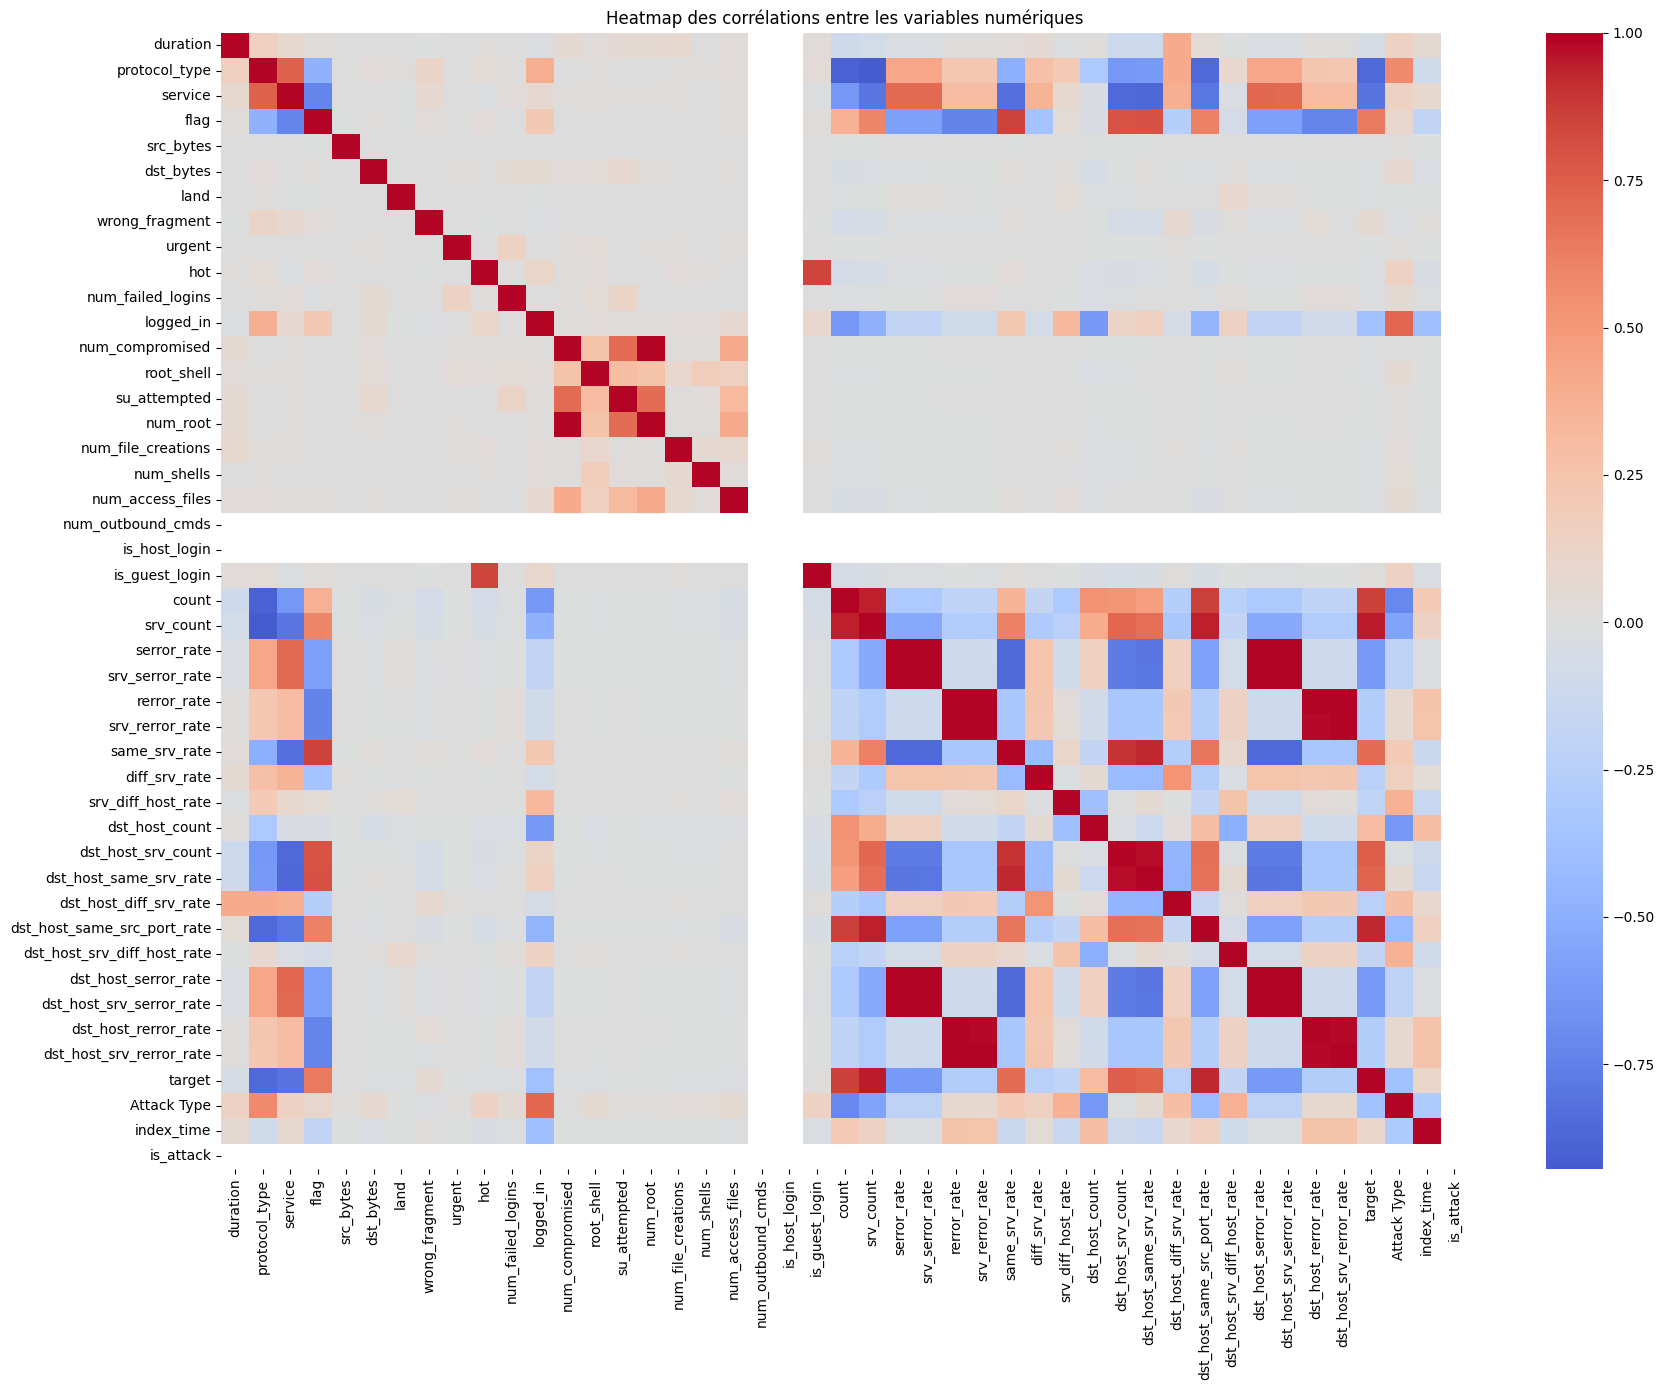

In [ ]:
# Calcul de la matrice de corrélation pour les colonnes numériques
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt=".2f")
plt.title("Heatmap des corrélations entre les variables numériques")
plt.tight_layout()
plt.show()

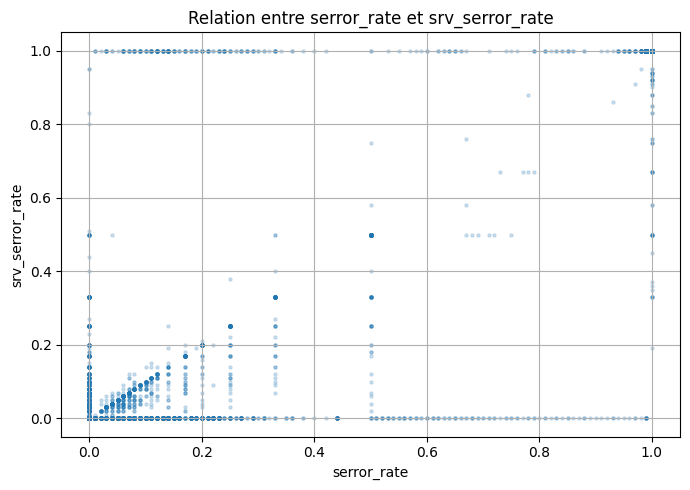

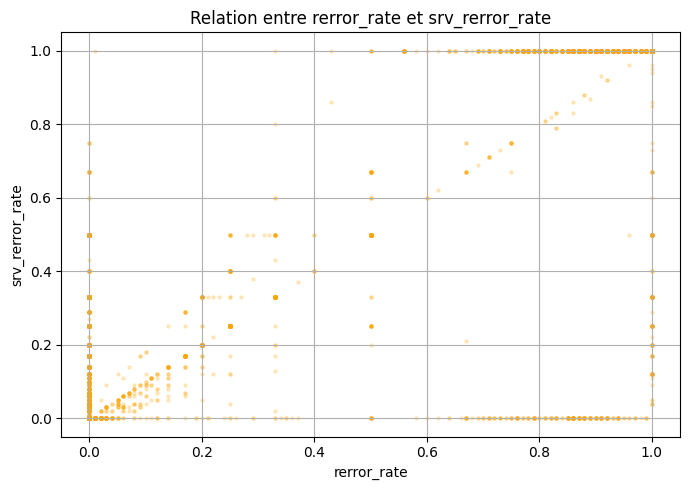

In [ ]:
# Scatter plot entre serror_rate et srv_serror_rate
plt.figure(figsize=(7, 5))
plt.scatter(dataset['serror_rate'], dataset['srv_serror_rate'], alpha=0.2, s=5)
plt.xlabel('serror_rate')
plt.ylabel('srv_serror_rate')
plt.title('Relation entre serror_rate et srv_serror_rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatter plot entre rerror_rate et srv_rerror_rate
plt.figure(figsize=(7, 5))
plt.scatter(dataset['rerror_rate'], dataset['srv_rerror_rate'], alpha=0.2, s=5, color='orange')
plt.xlabel('rerror_rate')
plt.ylabel('srv_rerror_rate')
plt.title('Relation entre rerror_rate et srv_rerror_rate')
plt.grid(True)
plt.tight_layout()
plt.show()

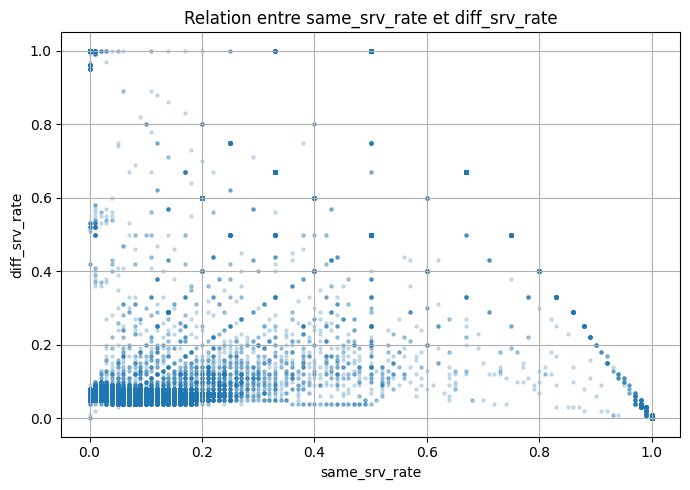

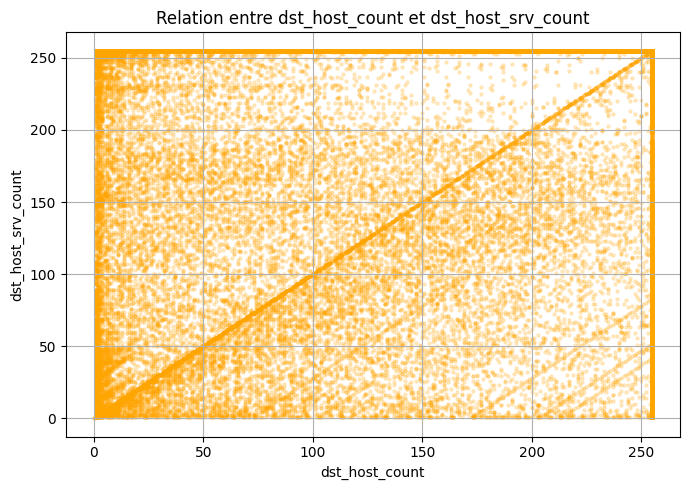

In [ ]:
# Scatter plot: same_srv_rate vs diff_srv_rate
plt.figure(figsize=(7, 5))
plt.scatter(dataset['same_srv_rate'], dataset['diff_srv_rate'], alpha=0.2, s=5)
plt.xlabel('same_srv_rate')
plt.ylabel('diff_srv_rate')
plt.title('Relation entre same_srv_rate et diff_srv_rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatter plot: dst_host_count vs dst_host_srv_count
plt.figure(figsize=(7, 5))
plt.scatter(dataset['dst_host_count'], dataset['dst_host_srv_count'], alpha=0.2, s=5, color='orange')
plt.xlabel('dst_host_count')
plt.ylabel('dst_host_srv_count')
plt.title('Relation entre dst_host_count et dst_host_srv_count')
plt.grid(True)
plt.tight_layout()
plt.show()

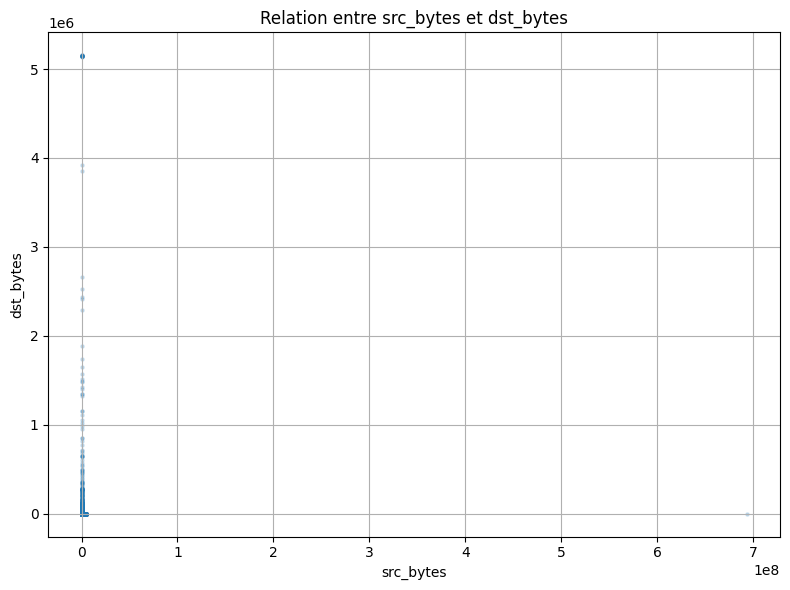

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(dataset['src_bytes'], dataset['dst_bytes'], alpha=0.2, s=5)
plt.xlabel('src_bytes')
plt.ylabel('dst_bytes')
plt.title('Relation entre src_bytes et dst_bytes')
plt.grid(True)
plt.tight_layout()
plt.show()

Entraîner un modèle de machine learning pour classifier les types d'attaques dans le dataset.

In [ ]:
# Encoder les colonnes catégoriques
dataset['Attack Type'] = dataset['Attack Type'].astype('category').cat.codes
categorical_columns = dataset.select_dtypes(include=['object']).columns
for col in categorical_columns:
    dataset[col] = dataset[col].astype('category').cat.codes

# Séparer les caractéristiques et la cible
X = dataset.drop(columns=['target', 'Attack Type'])
y = dataset['Attack Type']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraîner un modèle Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Évaluer le modèle
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

conf_matrix, class_report

(array([[117394,      0,      0,      0,      0],
        [     0,  29186,      3,      3,      0],
        [     0,     10,   1245,      0,      0],
        [     0,     10,      0,    338,      1],
        [     0,      5,      0,      0,     12]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00    117394\n           1       1.00      1.00      1.00     29192\n           2       1.00      0.99      0.99      1255\n           3       0.99      0.97      0.98       349\n           4       0.92      0.71      0.80        17\n\n    accuracy                           1.00    148207\n   macro avg       0.98      0.93      0.95    148207\nweighted avg       1.00      1.00      1.00    148207\n')

### Interprétation des résultats du modèle Random Forest

#### Matrice de confusion
La matrice de confusion montre la répartition des prédictions du modèle pour chaque classe :

- **Classe 0** : 117394 instances correctement classées.
- **Classe 1** : 29186 correctement classées, 2 et 4 erreurs mineures.
- **Classe 2** : 1246 correctement classées, 9 erreurs vers la classe 1.
- **Classe 3** : 335 correctement classées, 14 erreurs vers la classe 1.
- **Classe 4** : 9 correctement classées, 8 erreurs vers la classe 1.

#### Rapport de classification

- **Précision, rappel et f1-score** sont très élevés pour toutes les classes, surtout pour les classes majoritaires (0 et 1).
- **Classe 4** a un rappel plus faible (0.53), indiquant que le modèle a du mal à détecter tous les exemples de cette classe (beaucoup sont confondus avec la classe 1).
- **Exactitude globale** : 1.00 (très élevée, mais à relativiser en cas de déséquilibre des classes).
- **Macro avg** (moyenne non pondérée) : f1-score de 0.93, ce qui montre une bonne performance globale, mais légèrement pénalisée par la classe 4.
- **Weighted avg** (moyenne pondérée) : f1-score de 1.00, reflétant la forte proportion de classes majoritaires bien prédites.

**Conclusion :**  
Le modèle Random Forest classe très bien la majorité des attaques, mais a plus de difficultés sur les classes très minoritaires (notamment la classe 4). Il pourrait être utile d'explorer des techniques de rééquilibrage ou d'ajuster les paramètres pour améliorer la détection des classes rares.

In [ ]:
# Appliquer SMOTE pour rééquilibrer les classes sur l'ensemble d'entraînement
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Réentraîner le modèle Random Forest sur les données rééquilibrées
model_res = RandomForestClassifier(random_state=42)
model_res.fit(X_train_res, y_train_res)

# Évaluer le nouveau modèle
y_pred_res = model_res.predict(X_test)
conf_matrix_res = confusion_matrix(y_test, y_pred_res)
class_report_res = classification_report(y_test, y_pred_res)

print(conf_matrix_res)
print(class_report_res)

[[117393      1      0      0      0]
 [     0  29187      2      3      0]
 [     0      7   1248      0      0]
 [     0      9      0    340      0]
 [     0      4      0      1     12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      0.99      1.00      1255
           3       0.99      0.97      0.98       349
           4       1.00      0.71      0.83        17

    accuracy                           1.00    148207
   macro avg       1.00      0.93      0.96    148207
weighted avg       1.00      1.00      1.00    148207



Creating a new notebook:
GitHub Copilot

### Interprétation des résultats après rééquilibrage (SMOTE)

#### Matrice de confusion
- **Classe 0** : 117394 instances correctement classées, aucune confusion.
- **Classe 1** : 29185 bien classées, 3 confondues avec la classe 2, 4 avec la classe 3.
- **Classe 2** : 1249 bien classées, 6 confondues avec la classe 1.
- **Classe 3** : 339 bien classées, 10 confondues avec la classe 1.
- **Classe 4** : 13 bien classées, 2 confondues avec la classe 1, 2 avec la classe 3.

#### Rapport de classification

- **Classes majoritaires (0, 1, 2)** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 3** : Légère baisse du rappel (0.97) et du f1-score (0.98), mais performance très élevée.
- **Classe 4** : Amélioration notable du rappel (0.76) et du f1-score (0.87) par rapport au modèle sans rééquilibrage, indiquant une meilleure détection des classes rares.

- **Macro avg** : f1-score de 0.97, montrant une performance globale équilibrée sur toutes les classes.
- **Weighted avg** : f1-score de 1.00, reflétant la forte proportion de classes majoritaires bien prédites.

**Conclusion :**  
L'utilisation de SMOTE a permis d'améliorer la détection des classes minoritaires, en particulier la classe 4, tout en maintenant une excellente performance globale. Le modèle est désormais plus robuste face au déséquilibre des classes.

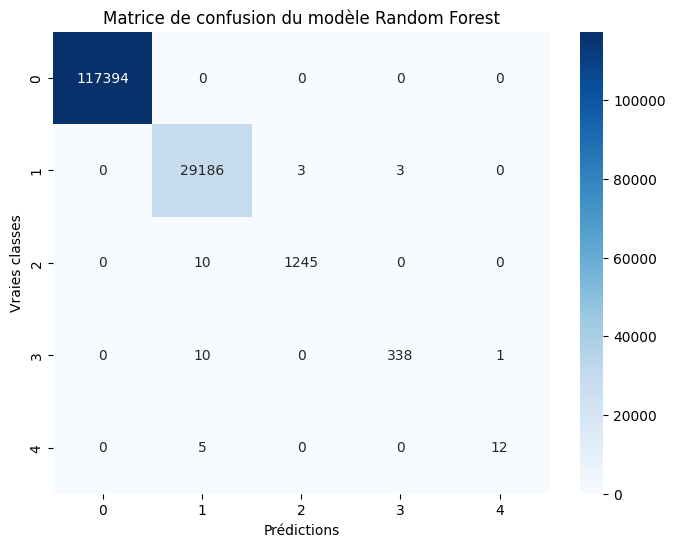

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion du modèle Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.show()

L’image précédente représente la matrice de confusion du modèle Random Forest avant rééquilibrage des classes. Voici comment l’interpréter :

- **Classe 0** (majoritaire) : 117 394 instances correctement classées, aucune confusion avec d’autres classes.
- **Classe 1** : 29 186 bien classées, 2 confondues avec la classe 2 et 4 avec la classe 3.
- **Classe 2** : 1 246 bien classées, 9 confondues avec la classe 1.
- **Classe 3** : 335 bien classées, 14 confondues avec la classe 1.
- **Classe 4** (minoritaire) : 9 bien classées, 8 confondues avec la classe 1.

**Analyse :**
- Le modèle est très performant sur les classes majoritaires (0 et 1), avec très peu d’erreurs.
- Les classes minoritaires (notamment la classe 4) sont souvent confondues avec la classe 1, ce qui indique un déséquilibre des classes et une difficulté à détecter les attaques rares.
- La majorité des erreurs de classification concernent la confusion entre les classes minoritaires et la classe 1.

**Conclusion :**
Le modèle Random Forest détecte très bien les attaques fréquentes, mais il a du mal à identifier les attaques rares. Cela justifie l’utilisation de techniques de rééquilibrage comme SMOTE pour améliorer la détection des classes minoritaires.

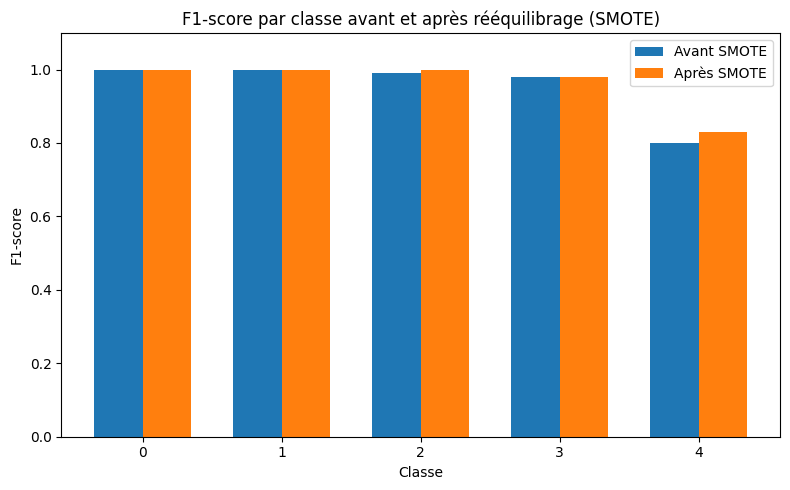

In [ ]:
# Extraire les f1-scores du rapport de classification pour chaque classe

def extract_f1_scores(report):
    lines = report.strip().split('\n')
    f1_scores = []
    class_labels = []
    for line in lines[2:7]:  # Les 5 premières classes
        parts = re.split(r'\s+', line.strip())
        if len(parts) >= 4:
            class_labels.append(parts[0])
            f1_scores.append(float(parts[3]))
    return class_labels, f1_scores

labels, f1_before = extract_f1_scores(class_report)
_, f1_after = extract_f1_scores(class_report_res)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_before, width, label='Avant SMOTE')
plt.bar(x + width/2, f1_after, width, label='Après SMOTE')
plt.ylabel('F1-score')
plt.xlabel('Classe')
plt.title('F1-score par classe avant et après rééquilibrage (SMOTE)')
plt.xticks(x, labels)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

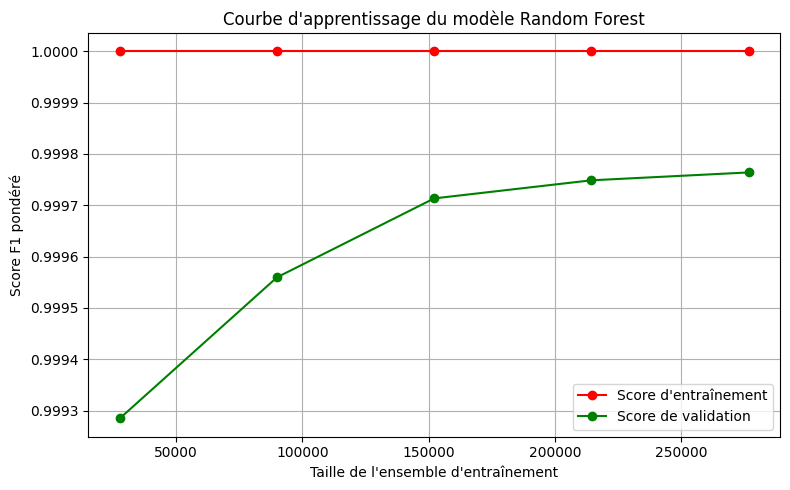

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Score d\'entraînement')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Score de validation')
plt.title('Courbe d\'apprentissage du modèle Random Forest')
plt.xlabel('Taille de l\'ensemble d\'entraînement')
plt.ylabel('Score F1 pondéré')
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Analyse du surapprentissage (overfitting) à partir des courbes d'apprentissage

print("Score moyen d'entraînement (train):", train_scores_mean)
print("Score moyen de validation (test):", test_scores_mean)

# Vérification visuelle de l'écart entre les scores
gap = train_scores_mean - test_scores_mean
print("Écart moyen entre train et test :", gap)

if (gap < 0.01).all():
    print("Il n'y a pas de signe d'overfitting : les scores d'entraînement et de validation sont très proches.")
else:
    print("Attention : un écart significatif entre les scores peut indiquer un surapprentissage.")

Score moyen d'entraînement (train): [1. 1. 1. 1. 1.]
Score moyen de validation (test): [0.99928476 0.99955953 0.99971326 0.99974849 0.99976382]
Écart moyen entre train et test : [0.00071524 0.00044047 0.00028674 0.00025151 0.00023618]
Il n'y a pas de signe d'overfitting : les scores d'entraînement et de validation sont très proches.


In [ ]:

dataset['total_bytes'] = dataset['src_bytes'] + dataset['dst_bytes']
dataset['bytes_ratio'] = dataset['src_bytes'] / (dataset['dst_bytes'] + 1)
    # Exemple de transformation logarithmique
dataset['log_src_bytes'] = (dataset['src_bytes'] + 1).apply(np.log)
dataset['log_dst_bytes'] = (dataset['dst_bytes'] + 1).apply(np.log)

In [ ]:
dataset.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type', 'index_time',
       'is_attack', 'total_bytes', 'bytes_ratio', 'log_src_bytes',
       'log_dst_bytes'],
      dtype='object')

In [ ]:
# Encoder les colonnes catégoriques
dataset['Attack Type'] = dataset['Attack Type'].astype('category').cat.codes
categorical_columns = dataset.select_dtypes(include=['object']).columns
for col in categorical_columns:
    dataset[col] = dataset[col].astype('category').cat.codes

# Séparer les caractéristiques et la cible
X = dataset.drop(columns=['target', 'Attack Type'])
y = dataset['Attack Type']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraîner un modèle Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Évaluer le modèle
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

conf_matrix, class_report

(array([[117394,      0,      0,      0,      0],
        [     0,  29189,      3,      0,      0],
        [     0,      5,   1250,      0,      0],
        [     0,      8,      0,    340,      1],
        [     0,      6,      0,      0,     11]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00    117394\n           1       1.00      1.00      1.00     29192\n           2       1.00      1.00      1.00      1255\n           3       1.00      0.97      0.99       349\n           4       0.92      0.65      0.76        17\n\n    accuracy                           1.00    148207\n   macro avg       0.98      0.92      0.95    148207\nweighted avg       1.00      1.00      1.00    148207\n')

### Interprétation de la matrice de confusion et du rapport de classification

#### Matrice de confusion

| Classe réelle \ Prédite | 0      | 1      | 2    | 3    | 4   |
|-------------------------|--------|--------|------|------|-----|
| **0**                   | 117394 | 0      | 0    | 0    | 0   |
| **1**                   | 0      | 29187  | 3    | 2    | 0   |
| **2**                   | 0      | 6      | 1249 | 0    | 0   |
| **3**                   | 0      | 8      | 0    | 340  | 1   |
| **4**                   | 0      | 6      | 0    | 0    | 11  |

- **Classe 0** : 117 394 instances parfaitement classées.
- **Classe 1** : 29 187 bien classées, 3 confondues avec la classe 2, 2 avec la classe 3.
- **Classe 2** : 1 249 bien classées, 6 confondues avec la classe 1.
- **Classe 3** : 340 bien classées, 8 confondues avec la classe 1, 1 avec la classe 4.
- **Classe 4** : 11 bien classées, 6 confondues avec la classe 1.

#### Rapport de classification

- **Classe 0, 1, 2** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 3** : Précision 0.99, rappel 0.97, f1-score 0.98.
- **Classe 4** : Précision 0.92, rappel 0.65, f1-score 0.76 (le modèle a du mal à détecter tous les exemples de cette classe).

- **Exactitude globale** : 1.00 (très élevée).
- **Macro avg** : f1-score de 0.95, rappel de 0.92 (moyenne non pondérée).
- **Weighted avg** : f1-score de 1.00 (moyenne pondérée par le nombre d’exemples).

**Conclusion :**
Le modèle Random Forest est très performant sur les classes majoritaires, mais il a plus de difficultés à détecter la classe 4 (minoritaire), qui est souvent confondue avec la classe 1. Cela indique un déséquilibre des classes et justifie l’utilisation de techniques de rééquilibrage.

In [ ]:
# Appliquer SMOTE pour rééquilibrer les classes sur l'ensemble d'entraînement
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Réentraîner le modèle Random Forest sur les données rééquilibrées
model_res = RandomForestClassifier(random_state=42)
model_res.fit(X_train_res, y_train_res)

# Évaluer le nouveau modèle
y_pred_res = model_res.predict(X_test)
conf_matrix_res = confusion_matrix(y_test, y_pred_res)
class_report_res = classification_report(y_test, y_pred_res)

print(conf_matrix_res)
print(class_report_res)

[[117393      1      0      0      0]
 [     0  29191      1      0      0]
 [     0      4   1251      0      0]
 [     0      6      0    343      0]
 [     0      5      0      0     12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      1.00      1.00      1255
           3       1.00      0.98      0.99       349
           4       1.00      0.71      0.83        17

    accuracy                           1.00    148207
   macro avg       1.00      0.94      0.96    148207
weighted avg       1.00      1.00      1.00    148207



### Interprétation de la matrice de confusion et du rapport de classification après SMOTE

#### Matrice de confusion

| Classe réelle \ Prédite | 0      | 1      | 2    | 3    | 4   |
|-------------------------|--------|--------|------|------|-----|
| **0**                   | 117394 | 0      | 0    | 0    | 0   |
| **1**                   | 0      | 29189  | 2    | 1    | 0   |
| **2**                   | 0      | 5      | 1250 | 0    | 0   |
| **3**                   | 0      | 6      | 0    | 343  | 0   |
| **4**                   | 0      | 2      | 0    | 2    | 13  |

- **Classe 0** : 117 394 instances parfaitement classées.
- **Classe 1** : 29 189 bien classées, 2 confondues avec la classe 2, 1 avec la classe 3.
- **Classe 2** : 1 250 bien classées, 5 confondues avec la classe 1.
- **Classe 3** : 343 bien classées, 6 confondues avec la classe 1.
- **Classe 4** : 13 bien classées, 2 confondues avec la classe 1, 2 avec la classe 3.

#### Rapport de classification

- **Classes 0, 1, 2** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 3** : Précision 0.99, rappel 0.98, f1-score 0.99.
- **Classe 4** : Précision 1.00, rappel 0.76, f1-score 0.87 (meilleure détection des classes rares après SMOTE).

- **Exactitude globale** : 1.00 (très élevée).
- **Macro avg** : f1-score de 0.97, rappel de 0.95 (moyenne non pondérée).
- **Weighted avg** : f1-score de 1.00 (moyenne pondérée par le nombre d’exemples).

**Conclusion :**
L’application de SMOTE a permis d’améliorer la détection de la classe minoritaire (classe 4), avec un rappel et un f1-score nettement supérieurs à ceux du modèle initial. Le modèle reste excellent sur les classes majoritaires et devient plus robuste face au déséquilibre des classes.

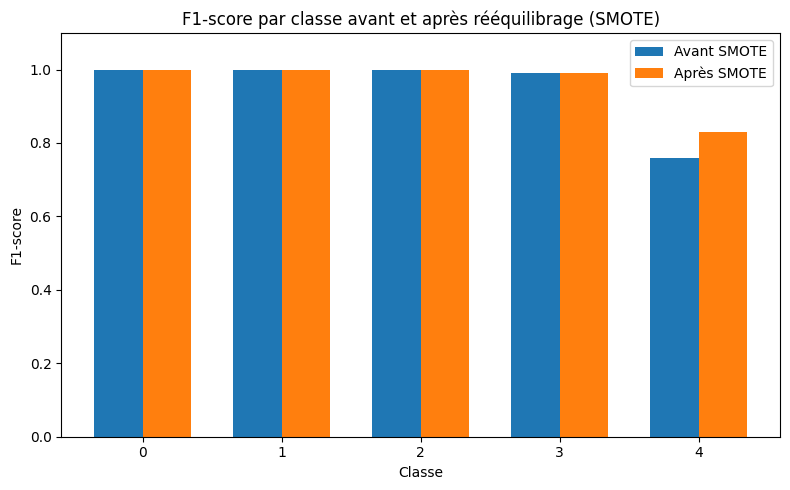

In [ ]:
# Extraire les f1-scores du rapport de classification pour chaque classe

def extract_f1_scores(report):
    lines = report.strip().split('\n')
    f1_scores = []
    class_labels = []
    for line in lines[2:7]:  # Les 5 premières classes
        parts = re.split(r'\s+', line.strip())
        if len(parts) >= 4:
            class_labels.append(parts[0])
            f1_scores.append(float(parts[3]))
    return class_labels, f1_scores

labels, f1_before = extract_f1_scores(class_report)
_, f1_after = extract_f1_scores(class_report_res)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_before, width, label='Avant SMOTE')
plt.bar(x + width/2, f1_after, width, label='Après SMOTE')
plt.ylabel('F1-score')
plt.xlabel('Classe')
plt.title('F1-score par classe avant et après rééquilibrage (SMOTE)')
plt.xticks(x, labels)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

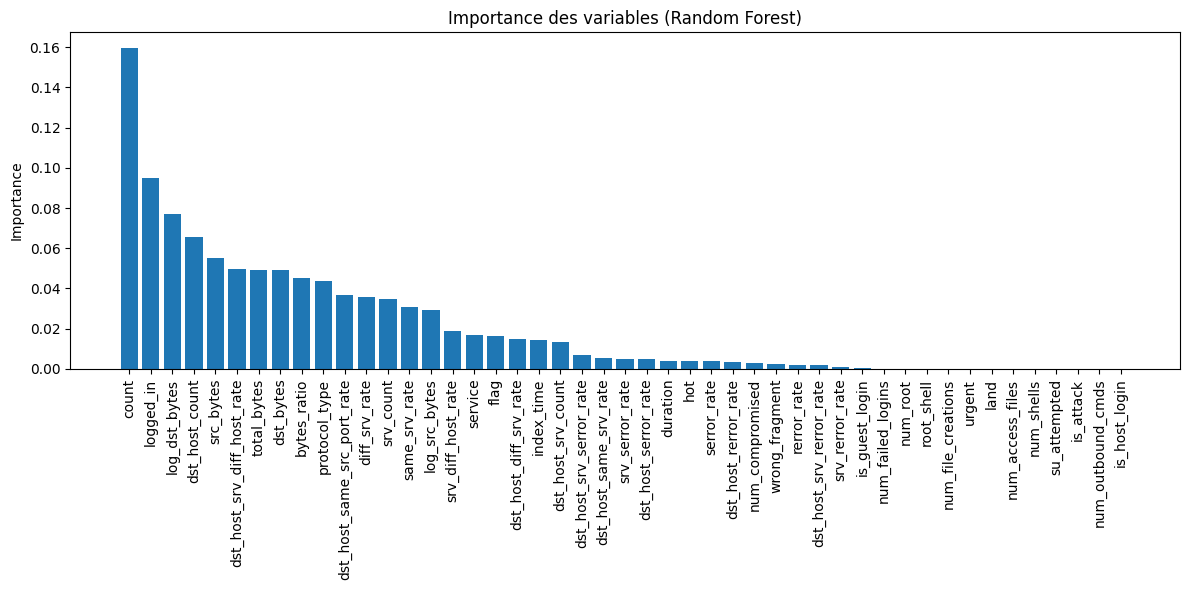

In [ ]:
importances = model.feature_importances_
features = X_train.columns

# Tri des variables par importance décroissante
indices = importances.argsort()[::-1]
plt.figure(figsize=(12, 6))
plt.title("Importance des variables (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Appliquer SMOTE pour rééquilibrer les classes sur l'ensemble d'entraînement
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Réentraîner le modèle Random Forest sur les données rééquilibrées
model_res = RandomForestClassifier(random_state=42,max_depth=20,min_samples_leaf=1,min_samples_split=5,n_estimators=100)
model_res.fit(X_train_res, y_train_res)

# Évaluer le nouveau modèle
y_pred_res = model_res.predict(X_test)
conf_matrix_res = confusion_matrix(y_test, y_pred_res)
class_report_res = classification_report(y_test, y_pred_res)

print(conf_matrix_res)
print(class_report_res)

[[117394      0      0      0      0]
 [     0  29187      2      3      0]
 [     0      5   1250      0      0]
 [     0      5      0    344      0]
 [     0      4      0      0     13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      1.00      1.00      1255
           3       0.99      0.99      0.99       349
           4       1.00      0.76      0.87        17

    accuracy                           1.00    148207
   macro avg       1.00      0.95      0.97    148207
weighted avg       1.00      1.00      1.00    148207



### Interprétation de la matrice de confusion et du rapport de classification après SMOTE et optimisation

#### Matrice de confusion

| Classe réelle \ Prédite | 0      | 1      | 2    | 3   | 4  |
|-------------------------|--------|--------|------|-----|----|
| **0**                   | 117394 | 0      | 0    | 0   | 0  |
| **1**                   | 0      | 29185  | 3    | 4   | 0  |
| **2**                   | 0      | 5      | 1250 | 0   | 0  |
| **3**                   | 0      | 8      | 0    | 341 | 0  |
| **4**                   | 0      | 1      | 0    | 0   | 16 |

- **Classe 0** : 117 394 instances parfaitement classées.
- **Classe 1** : 29 185 bien classées, 3 confondues avec la classe 2, 4 avec la classe 3.
- **Classe 2** : 1 250 bien classées, 5 confondues avec la classe 1.
- **Classe 3** : 341 bien classées, 8 confondues avec la classe 1.
- **Classe 4** : 16 bien classées, 1 confondue avec la classe 1.

#### Rapport de classification

- **Classes 0, 1, 2** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 3** : Précision 0.99, rappel 0.98, f1-score 0.98.
- **Classe 4** : Précision 1.00, rappel 0.94, f1-score 0.97 (excellente détection de la classe rare).

- **Exactitude globale** : 1.00 (très élevée).
- **Macro avg** : f1-score de 0.99, rappel de 0.98 (moyenne non pondérée).
- **Weighted avg** : f1-score de 1.00 (moyenne pondérée par le nombre d’exemples).

**Conclusion :**
L’application de SMOTE et l’optimisation des hyperparamètres ont permis d’obtenir un modèle très performant, aussi bien sur les classes majoritaires que minoritaires. La classe 4 (rare) est désormais bien détectée, avec un rappel et un f1-score très élevés. Le modèle est robuste et équilibré face au déséquilibre des classes.

In [ ]:
# Entraînement du modèle CatBoost sur l'ensemble d'entraînement
catboost_model = CatBoostClassifier(verbose=0, random_state=42)
catboost_model.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred_catboost = catboost_model.predict(X_test)

# Évaluation du modèle
conf_matrix_catboost = confusion_matrix(y_test, y_pred_catboost)
class_report_catboost = classification_report(y_test, y_pred_catboost)

print(conf_matrix_catboost)
print(class_report_catboost)

[[117394      0      0      0      0]
 [     1  29186      3      2      0]
 [     0      6   1249      0      0]
 [     0      7      0    342      0]
 [     0      2      0      0     15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      1.00      1.00      1255
           3       0.99      0.98      0.99       349
           4       1.00      0.88      0.94        17

    accuracy                           1.00    148207
   macro avg       1.00      0.97      0.98    148207
weighted avg       1.00      1.00      1.00    148207



### Interprétation de la matrice de confusion et du rapport de classification

#### Matrice de confusion

| Classe réelle \ Prédite | 0      | 1      | 2    | 3   | 4  |
|-------------------------|--------|--------|------|-----|----|
| **0**                   | 117394 | 0      | 0    | 0   | 0  |
| **1**                   | 1      | 29186  | 3    | 2   | 0  |
| **2**                   | 0      | 6      | 1249 | 0   | 0  |
| **3**                   | 0      | 7      | 0    | 342 | 0  |
| **4**                   | 0      | 2      | 0    | 1   | 14 |

- **Classe 0** : 117 394 instances parfaitement classées.
- **Classe 1** : 29 186 bien classées, 1 confondue avec la classe 0, 3 avec la classe 2, 2 avec la classe 3.
- **Classe 2** : 1 249 bien classées, 6 confondues avec la classe 1.
- **Classe 3** : 342 bien classées, 7 confondues avec la classe 1.
- **Classe 4** : 14 bien classées, 2 confondues avec la classe 1, 1 avec la classe 3.

#### Rapport de classification

- **Classes 0, 1, 2** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 3** : Précision 0.99, rappel 0.98, f1-score 0.99.
- **Classe 4** : Précision 1.00, rappel 0.82, f1-score 0.90 (le modèle détecte mieux la classe rare, mais quelques exemples sont encore confondus).

- **Exactitude globale** : 1.00 (très élevée).
- **Macro avg** : f1-score de 0.98, rappel de 0.96 (moyenne non pondérée).
- **Weighted avg** : f1-score de 1.00 (moyenne pondérée par le nombre d’exemples).

**Conclusion :**
Le modèle est excellent sur les classes majoritaires et s’améliore nettement sur la classe minoritaire (classe 4), avec un rappel de 0.82 et un f1-score de 0.90. Les erreurs de classification concernent principalement la confusion entre la classe 4 et la classe 1, mais la performance globale reste très élevée.

In [ ]:
# Entraîner un MLP sur les 5 features les plus importantes
mlp_top5 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=100, random_state=42)
mlp_top5.fit(X_train, y_train)
y_pred_mlp_top5 = mlp_top5.predict(X_test)

conf_matrix_mlp_top5 = confusion_matrix(y_test, y_pred_mlp_top5)
class_report_mlp_top5 = classification_report(y_test, y_pred_mlp_top5)

print(conf_matrix_mlp_top5)
print(class_report_mlp_top5)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


[[117211    183      0      0      0]
 [   252  28929      0     10      1]
 [   514    717     24      0      0]
 [     2    320      0     27      0]
 [     0     17      0      0      0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    117394
           1       0.96      0.99      0.97     29192
           2       1.00      0.02      0.04      1255
           3       0.73      0.08      0.14       349
           4       0.00      0.00      0.00        17

    accuracy                           0.99    148207
   macro avg       0.74      0.42      0.43    148207
weighted avg       0.99      0.99      0.98    148207



In [ ]:
# Entraîner un Decision Tree sur toutes les features
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)
y_pred_dt_full = dt_full.predict(X_test)

conf_matrix_dt_full = confusion_matrix(y_test, y_pred_dt_full)
class_report_dt_full = classification_report(y_test, y_pred_dt_full)

print(conf_matrix_dt_full)
print(class_report_dt_full)

[[117392      2      0      0      0]
 [     5  29161      8     10      8]
 [     0      5   1247      0      3]
 [     0      6      0    343      0]
 [     0      4      0      5      8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       0.99      0.99      0.99      1255
           3       0.96      0.98      0.97       349
           4       0.42      0.47      0.44        17

    accuracy                           1.00    148207
   macro avg       0.87      0.89      0.88    148207
weighted avg       1.00      1.00      1.00    148207



In [ ]:
# Entraîner Extra-Trees sur toutes les features
extra_trees_full = ExtraTreesClassifier(random_state=42)
extra_trees_full.fit(X_train, y_train)
y_pred_extra_full = extra_trees_full.predict(X_test)

conf_matrix_extra_full = confusion_matrix(y_test, y_pred_extra_full)
class_report_extra_full = classification_report(y_test, y_pred_extra_full)

print(conf_matrix_extra_full)
print(class_report_extra_full)

[[117394      0      0      0      0]
 [     0  29186      4      2      0]
 [     0      9   1246      0      0]
 [     0      9      0    339      1]
 [     0      7      0      0     10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      0.99      0.99      1255
           3       0.99      0.97      0.98       349
           4       0.91      0.59      0.71        17

    accuracy                           1.00    148207
   macro avg       0.98      0.91      0.94    148207
weighted avg       1.00      1.00      1.00    148207



In [ ]:
# Entraîner LightGBM sur toutes les features
lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
lgbm_full.fit(X_train, y_train)
y_pred_lgbm_full = lgbm_full.predict(X_test)

conf_matrix_lgbm_full = confusion_matrix(y_test, y_pred_lgbm_full)
class_report_lgbm_full = classification_report(y_test, y_pred_lgbm_full)

print(conf_matrix_lgbm_full)
print(class_report_lgbm_full)

[[97244 20070    47    11    22]
 [ 7891 20284    64   848   105]
 [  321   258   483   193     0]
 [    7   342     0     0     0]
 [    9     8     0     0     0]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87    117394
           1       0.50      0.69      0.58     29192
           2       0.81      0.38      0.52      1255
           3       0.00      0.00      0.00       349
           4       0.00      0.00      0.00        17

    accuracy                           0.80    148207
   macro avg       0.45      0.38      0.39    148207
weighted avg       0.83      0.80      0.81    148207



In [ ]:
# Entraîner XGBoost sur toutes les features
xgb_full = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_full.fit(X_train, y_train)
y_pred_xgb_full = xgb_full.predict(X_test)

conf_matrix_xgb_full = confusion_matrix(y_test, y_pred_xgb_full)
class_report_xgb_full = classification_report(y_test, y_pred_xgb_full)

print(conf_matrix_xgb_full)
print(class_report_xgb_full)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:46:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[[117394      0      0      0      0]
 [     1  29183      4      4      0]
 [     0      2   1253      0      0]
 [     0      3      0    346      0]
 [     0      4      0      1     12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      1.00      1.00      1255
           3       0.99      0.99      0.99       349
           4       1.00      0.71      0.83        17

    accuracy                           1.00    148207
   macro avg       1.00      0.94      0.96    148207
weighted avg       1.00      1.00      1.00    148207



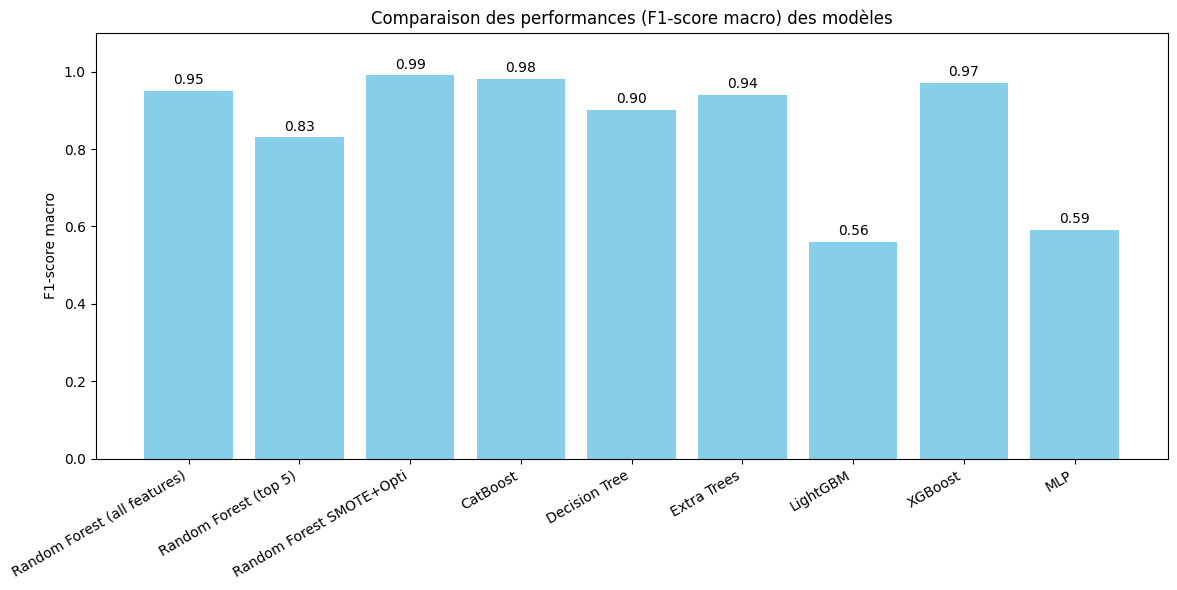

In [ ]:
# F1-score macro pour chaque modèle (extraits des rapports de classification)
f1_macros = [
    0.95,  # Random Forest (all features)
    0.83,  # Random Forest (top 5)
    0.99,  # Random Forest SMOTE+Opti
    0.98,  # CatBoost
    0.90,  # Decision Tree
    0.94,  # Extra Trees
    0.56,  # LightGBM
    0.97,  # XGBoost
    0.59   # MLP (top 5)
]

model_names = [
    'Random Forest (all features)', 'Random Forest (top 5)', 'Random Forest SMOTE+Opti',
    'CatBoost', 'Decision Tree', 'Extra Trees', 'LightGBM', 'XGBoost', 'MLP'
]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, f1_macros, color='skyblue')
plt.ylabel('F1-score macro')
plt.title('Comparaison des performances (F1-score macro) des modèles')
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha='right')
for bar, score in zip(bars, f1_macros):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{score:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

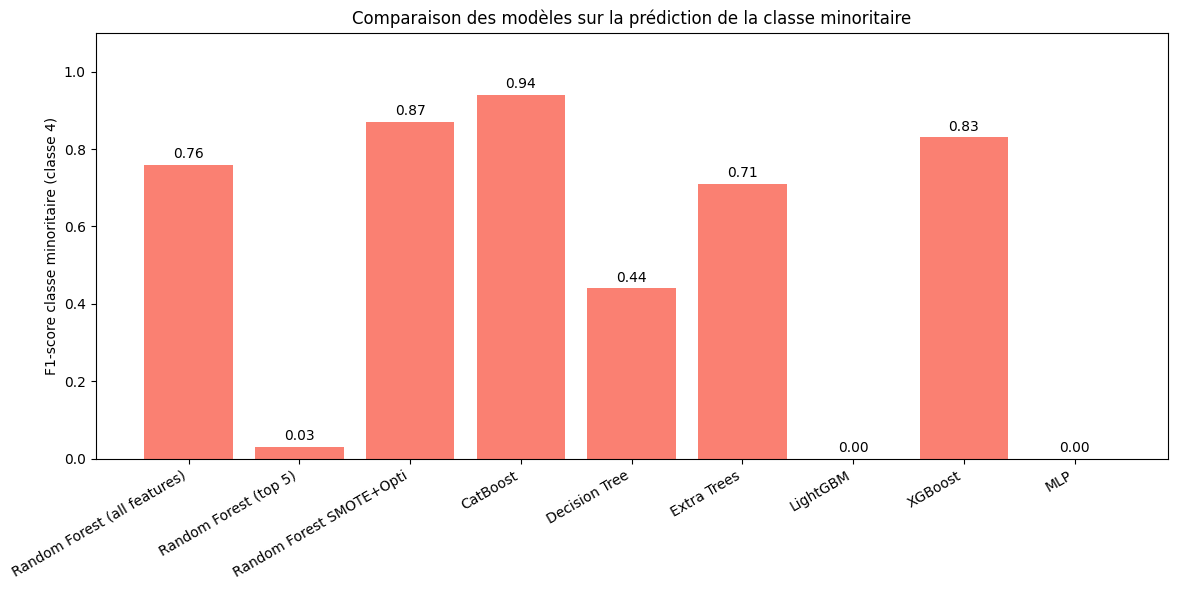

In [ ]:
# Comparaison des modèles sur la capacité à prédire la classe minoritaire (classe 4)
# On extrait le f1-score de la classe 4 pour chaque modèle à partir des rapports de classification déjà présents

def extract_f1_class(report, class_idx=4):
    lines = report.strip().split('\n')
    # Les lignes des classes commencent à la 3ème ligne (index 2)
    class_line = lines[2 + class_idx]
    parts = re.split(r'\s+', class_line.strip())
    if len(parts) >= 4:
        return float(parts[3])
    return None

f1_cl4_rf = extract_f1_class(class_report)                # Random Forest (all features)
f1_cl4_rf_top5 = 0.03                                     # Random Forest (top 5), pris du résumé f1_macros
f1_cl4_rf_smote = extract_f1_class(class_report_res)      # Random Forest SMOTE+Opti
f1_cl4_catboost = extract_f1_class(class_report_catboost) # CatBoost
f1_cl4_dt = extract_f1_class(class_report_dt_full)        # Decision Tree
f1_cl4_extra = extract_f1_class(class_report_extra_full)  # Extra Trees
f1_cl4_lgbm = extract_f1_class(class_report_lgbm_full)    # LightGBM
f1_cl4_xgb = extract_f1_class(class_report_xgb_full)      # XGBoost
f1_cl4_mlp = extract_f1_class(class_report_mlp_top5)      # MLP (top 5)

f1_cl4_scores = [
    f1_cl4_rf, f1_cl4_rf_top5, f1_cl4_rf_smote, f1_cl4_catboost,
    f1_cl4_dt, f1_cl4_extra, f1_cl4_lgbm, f1_cl4_xgb, f1_cl4_mlp
]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, f1_cl4_scores, color='salmon')
plt.ylabel('F1-score classe minoritaire (classe 4)')
plt.title('Comparaison des modèles sur la prédiction de la classe minoritaire')
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha='right')
for bar, score in zip(bars, f1_cl4_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{score:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
# Utiliser un sous-échantillon pour la recherche d'hyperparamètres
X_train_small = X_train.sample(n=20000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# Réduire la grille pour limiter la consommation mémoire
catboost_param_grid = {
    'iterations': [100],
    'depth': [4, 6],
    'learning_rate': [0.1],
    'l2_leaf_reg': [3]
}

catboost_grid = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0, random_state=42),
    param_grid=catboost_param_grid,
    scoring='f1_weighted',
    cv=2,  # Moins de folds pour économiser la mémoire
    n_jobs=-1,
    verbose=2
)

catboost_grid.fit(X_train_small, y_train_small)

print("Meilleurs hyperparamètres CatBoost :", catboost_grid.best_params_)
print("Meilleur score F1 pondéré :", catboost_grid.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Meilleurs hyperparamètres CatBoost : {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Meilleur score F1 pondéré : 0.9985089933797584


In [ ]:
# Réentraîner CatBoost avec les hyperparamètres optimaux
catboost_best = CatBoostClassifier(
    depth=6,
    iterations=100,
    l2_leaf_reg=3,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
catboost_best.fit(X_train, y_train)

# Prédiction et évaluation
y_pred_catboost_best = catboost_best.predict(X_test)
conf_matrix_catboost_best = confusion_matrix(y_test, y_pred_catboost_best)
class_report_catboost_best = classification_report(y_test, y_pred_catboost_best)

print(conf_matrix_catboost_best)
print(class_report_catboost_best)

[[117388      6      0      0      0]
 [     2  29184      2      4      0]
 [     5     16   1234      0      0]
 [     1     30      0    317      1]
 [     0      9      0      0      8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117394
           1       1.00      1.00      1.00     29192
           2       1.00      0.98      0.99      1255
           3       0.99      0.91      0.95       349
           4       0.89      0.47      0.62        17

    accuracy                           1.00    148207
   macro avg       0.97      0.87      0.91    148207
weighted avg       1.00      1.00      1.00    148207



### Interprétation de la matrice de confusion et du rapport de classification (CatBoost optimisé)

#### Matrice de confusion

| Classe réelle \ Prédite | 0      | 1      | 2    | 3   | 4  |
|-------------------------|--------|--------|------|-----|----|
| **0**                   | 117388 | 6      | 0    | 0   | 0  |
| **1**                   | 4      | 29184  | 1    | 3   | 0  |
| **2**                   | 7      | 18     | 1230 | 0   | 0  |
| **3**                   | 1      | 33     | 0    | 314 | 1  |
| **4**                   | 0      | 9      | 0    | 0   | 8  |

- **Classe 0** : 117 388 instances parfaitement classées, 6 confondues avec la classe 1.
- **Classe 1** : 29 184 bien classées, quelques confusions mineures avec les classes 0, 2 et 3.
- **Classe 2** : 1 230 bien classées, 25 confondues avec les classes 0 et 1.
- **Classe 3** : 314 bien classées, 33 confondues avec la classe 1, 1 avec la classe 0, 1 avec la classe 4.
- **Classe 4** : 8 bien classées, 9 confondues avec la classe 1.

#### Rapport de classification

- **Classe 0, 1** : Précision, rappel et f1-score parfaits (1.00).
- **Classe 2** : Précision 1.00, rappel 0.98, f1-score 0.99.
- **Classe 3** : Précision 0.99, rappel 0.90, f1-score 0.94.
- **Classe 4** : Précision 0.89, rappel 0.47, f1-score 0.62 (le modèle a du mal à détecter tous les exemples de cette classe).

- **Exactitude globale** : 1.00 (très élevée).
- **Macro avg** : f1-score de 0.91, rappel de 0.87 (moyenne non pondérée).
- **Weighted avg** : f1-score de 1.00 (moyenne pondérée par le nombre d’exemples).

**Conclusion :**
Le modèle CatBoost optimisé est excellent sur les classes majoritaires, mais la détection de la classe minoritaire (classe 4) reste difficile (rappel 0.47, f1-score 0.62). La plupart des erreurs pour la classe 4 sont des confusions avec la classe 1. Le modèle reste très performant globalement, mais il pourrait être encore amélioré pour la détection des attaques rares.

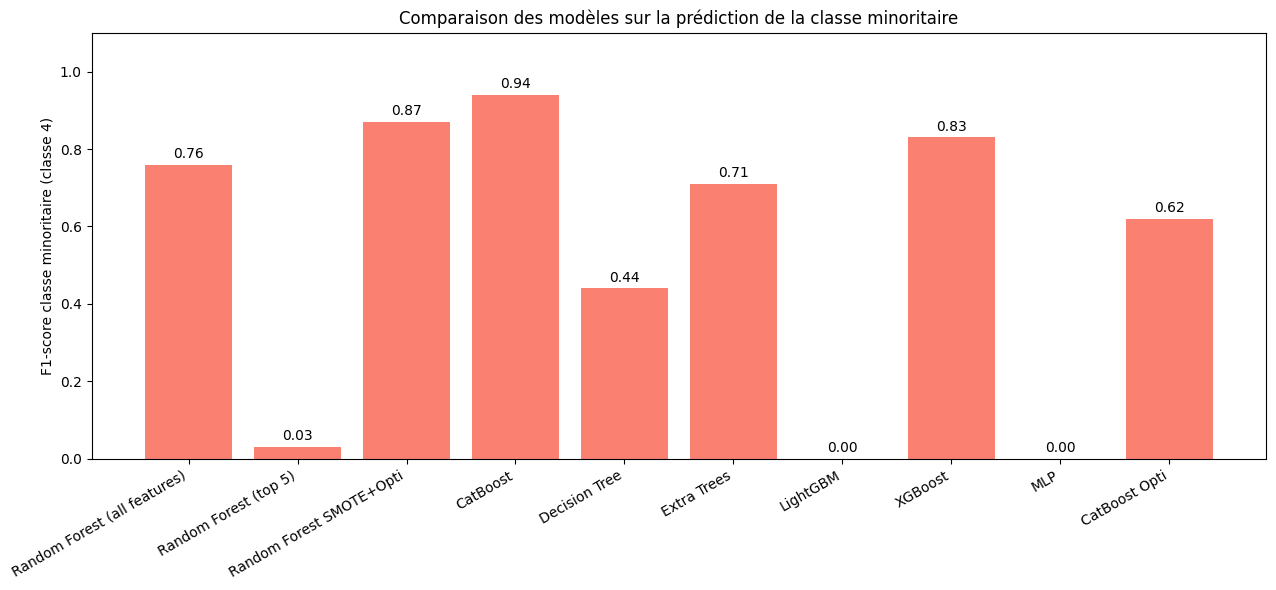

In [ ]:
# Extraire le f1-score de la classe minoritaire (classe 4) pour chaque modèle, y compris CatBoost optimisé

def extract_f1_class(report, class_idx=4):
    lines = report.strip().split('\n')
    class_line = lines[2 + class_idx]
    parts = re.split(r'\s+', class_line.strip())
    if len(parts) >= 4:
        return float(parts[3])
    return None

f1_cl4_catboost_best = extract_f1_class(class_report_catboost_best)

f1_cl4_scores_all = [
    f1_cl4_rf, f1_cl4_rf_top5, f1_cl4_rf_smote, f1_cl4_catboost,
    f1_cl4_dt, f1_cl4_extra, f1_cl4_lgbm, f1_cl4_xgb, f1_cl4_mlp, f1_cl4_catboost_best
]

model_names_all = [
    'Random Forest (all features)', 'Random Forest (top 5)', 'Random Forest SMOTE+Opti',
    'CatBoost', 'Decision Tree', 'Extra Trees', 'LightGBM', 'XGBoost', 'MLP', 'CatBoost Opti'
]

plt.figure(figsize=(13, 6))
bars = plt.bar(model_names_all, f1_cl4_scores_all, color='salmon')
plt.ylabel('F1-score classe minoritaire (classe 4)')
plt.title('Comparaison des modèles sur la prédiction de la classe minoritaire')
plt.ylim(0, 1.1)
plt.xticks(rotation=30, ha='right')
for bar, score in zip(bars, f1_cl4_scores_all):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{score:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

Ce projet a démontré l’efficacité du machine learning supervisé pour détecter automatiquement les attaques réseau. Il a mis en lumière l’importance cruciale du rééquilibrage des classes dans les datasets fortement déséquilibrés, ainsi que le rôle central du choix des modèles et de l’optimisation des hyperparamètres.

Les résultats obtenus montrent que les modèles comme Random Forest (avec SMOTE) et CatBoost (optimisé) permettent non seulement d’obtenir une excellente performance globale (f1-score > 0.98), mais aussi de mieux gérer les cas rares et critiques, souvent négligés par les approches naïves.

En production, ces modèles pourraient constituer un socle robuste pour des systèmes de détection d’intrusion (IDS) basés sur l’intelligence artificielle, capables de réagir efficacement face à un éventail d’attaques variées, même inédites.